# Setup

In [2401]:
import math

import torch
import matplotlib.pyplot as plt
import numpy as np

torch.set_default_dtype(torch.float64)

In [2417]:
def get_gaussian_probs(positions, mean, cov, norm_by = None):
    (det_sign, det_mag) = torch.linalg.slogdet(2*math.pi*cov)
    prec = torch.linalg.inv(cov)
    centered = positions - mean
    exp = torch.einsum("...i,...ij,...j", centered, prec, centered)
    log_density = -0.5*det_sign*det_mag - 0.5*exp
    density = torch.exp(torch.clamp(log_density, -50))
    norm = density.sum() if norm_by is None else density.sum(norm_by, keepdim = True)
    normalized = density / norm
    return normalized

def get_cov(elements):
    diagonal = torch.nn.functional.softplus(torch.diagonal(elements, 0, -2, -1))
    chol = torch.diag_embed(diagonal) + torch.tril(elements, -1)
    cov = torch.einsum("...ij,...kj->...ik", chol, chol)
    return cov

def get_grid(bounds, resolutions):
    grids_1d = [torch.linspace(bound[0], bound[1], res) for (bound, res) in zip(bounds, resolutions)]
    grid = torch.stack(torch.meshgrid(*grids_1d, indexing = "ij"), -1)
    return grid

def get_prob_func(num_vars, var_indices, cond_by):
    def get_prob(densities):
        shapes = {index: size for (index, size) in zip(var_indices, densities.shape)}
        new_shape = tuple((shapes[i] if i in shapes else 1) for i in range(num_vars))
        reshaped = densities.reshape(new_shape)
        probs = Probabilities(reshaped, cond_by)
        return probs
    return get_prob

class Probabilities():
    def __init__(self, prob_tensor, cond = []):
        self.probs = prob_tensor
        self.cond = set(cond)
        self.num_vars = self.probs.dim()
        self.all_vars = list(range(self.num_vars))
    
    def transform(self, out_vars, cond_vars = []):
        cond_vars = self.cond.union(cond_vars)
        summed = [var for var in self.all_vars if var not in cond_vars]
        normalized = self.probs / self.probs.sum(summed, keepdim = True)
        marg_variables = [i for i in self.all_vars if i not in cond_vars.union(out_vars)]
        if marg_variables:
            probs = torch.sum(normalized, dim = tuple(marg_variables), keepdim = True)
        else:
            probs = normalized
        return Probabilities(probs, cond_vars)

    def add(self, prob_instances, weights, self_weight):
        new_probs = sum([w*inst.probs for (inst, w) in zip(prob_instances, weights)])
        new_probs = self_weight*self.probs + new_probs
        return Probabilities(new_probs, self.cond)

    def mul(self, prob_instances):
        new_cond = self.cond.intersection(*[inst.cond for inst in prob_instances])
        new_probs = math.prod([inst.probs for inst in prob_instances])
        return Probabilities(self.probs*new_probs, new_cond)

    def average(self, target):
        summed = [var for var in self.all_vars if var not in self.cond]
        average = (self.probs*target).sum(dim = summed, keepdim = True)
        return average
    
    def entropy(self, target = None):
        target_probs = self.probs if target is None else target.probs
        entropy = -self.average(torch.log2(target_probs))
        return entropy

    def divergence(self, target):
        divergence = self.entropy(target) - self.entropy()
        return divergence

class Data():
    def __init__(self, data_grid, means, covs, prob_func):
        num_modalities = len(means)
        means = [torch.as_tensor(mean) for mean in means]
        covs = [torch.as_tensor(cov) for cov in covs]
        densities = [get_gaussian_probs(data_grid, mean, cov).flatten() 
                     for (mean, cov) in zip(means, covs)]
        einsum_args = [None]*(2*num_modalities)
        einsum_args[::2] = densities
        einsum_args[1::2] = [[i] for i in range(num_modalities)]
        combined = torch.einsum(*einsum_args, list(range(num_modalities)))
        self.probs = prob_func(combined)
    
    def __call__(self):
        return self.probs

class MargPrior():
    def __init__(self, latent_grid, var, prob_func):
        latent_dim = latent_grid.shape[-1]
        means = torch.zeros_like(latent_grid)
        cov = var*torch.eye(latent_dim)
        densities = get_gaussian_probs(latent_grid, means, cov).flatten()
        self.probs = prob_func(densities)

    def __call__(self):
        return self.probs

class CondPrior():
    def __init__(self, latent_grid, var, norm_by, prob_func):
        latent_dim = latent_grid.ndim - 1
        num_states = latent_grid[..., 0].numel()
        mean_shape = latent_grid.shape[:-1] + tuple(1 for dim in latent_grid.shape[:-1]) + (latent_dim,)
        cov_shape = 2*tuple(1 for dim in latent_grid.shape[:-1]) + (latent_dim, latent_dim)
        means = latent_grid.reshape(mean_shape)
        cov = var*torch.eye(latent_dim).reshape(cov_shape)
        latent_grid_expand = latent_grid.reshape(tuple(1 for dim in latent_grid.shape[:-1]) + latent_grid.shape)
        norm_by = tuple(range(norm_by*latent_dim, (norm_by + 1)*latent_dim))
        densities = get_gaussian_probs(latent_grid_expand, means, cov, norm_by)
        reshaped = shape_func(densities.reshape(num_states, num_states))
        self.probs = prob_func(reshaped)

    def __call__(self):
        return self.probs

class Encoder(torch.nn.Module):
    def __init__(self, data_grid, latent_grid, prob_func):
        super().__init__()
        (data_dim, latent_dim) = (data_grid.shape[-1], latent_grid.shape[-1])
        mean_shape =  data_grid.shape[:-1] + tuple(1 for dim in latent_grid.shape[:-1]) + (latent_dim,)
        chol_shape = data_grid.shape[:-1] + tuple(1 for dim in latent_grid.shape[:-1]) + (latent_dim, latent_dim)
        self.means = torch.nn.Parameter(torch.zeros(mean_shape))
        self.chol = torch.nn.Parameter(torch.zeros(chol_shape) + torch.eye(latent_dim))
        self.latent_grid = latent_grid.reshape(tuple(1 for dim in data_grid.shape[:-1]) + latent_grid.shape)
        self.norm_by = tuple(range(data_dim, latent_dim + data_dim))
        self.prob_func = prob_func
        self.num_data_states = data_grid[..., 0].numel()
        self.num_latent_states = latent_grid[..., 0].numel()

    def forward(self):
        cov = get_cov(self.chol)
        probs = get_gaussian_probs(self.latent_grid, self.means, cov, self.norm_by)
        reshaped = probs.reshape(self.num_data_states, self.num_latent_states)
        return self.prob_func(reshaped)

class GaussianDecoder(torch.nn.Module):
    def __init__(self, data_grid, latent_grid, var, prob_func):
        super().__init__()
        (data_dim, latent_dim) = (data_grid.shape[-1], latent_grid.shape[-1])
        mean_shape = tuple(1 for dim in data_grid.shape[:-1]) + latent_grid.shape[:-1] + (data_dim,)
        self.means = torch.nn.Parameter(torch.zeros(mean_shape))
        self.cov = var*torch.eye(data_dim)
        self.data_grid = data_grid.reshape(data_grid.shape[:-1] + tuple(1 for dim in latent_grid.shape[:-1]) + (data_dim,))
        self.norm_by = tuple(range(data_dim))
        self.prob_func = prob_func
        self.num_data_states = data_grid[..., 0].numel()
        self.num_latent_states = latent_grid[..., 0].numel()

    def forward(self):
        probs = get_gaussian_probs(self.data_grid, self.means, self.cov, self.norm_by)
        reshaped = probs.reshape(self.num_data_states, self.num_latent_states)
        return self.prob_func(reshaped)

class UnconstrainedDecoder(torch.nn.Module):
    def __init__(self, data_grid, latent_grid, prob_func):
        super().__init__()
        self.num_data_states = data_grid[..., 0].numel()
        self.num_latent_states = latent_grid[..., 0].numel()
        self.params = torch.nn.Parameter(torch.randn([self.num_data_states, self.num_latent_states]).double())
        self.prob_func = prob_func

    def forward(self):
        probs = torch.nn.functional.softmax(self.params, 0)
        return self.prob_func(probs)

class ExactDecoder(torch.nn.Module):
    def __init__(self, data_grid, latent_grid, num_modalities, index):
        super().__init__()
        data_dim = data_grid.shape[-1]
        param_shape = (1, latent_grid[..., 0].numel(), data_dim)
        self.params = torch.nn.Parameter(torch.zeros(param_shape))
        output_shape = [1]*2*num_modalities
        output_shape[index] = data_grid.numel()
        output_shape[num_modalities + index] = param_shape[1]
        self.output_shape = output_shape
        self.flat_grid = data_grid.flatten(end_dim = -2)[:, None]

    def forward(self):
        error = torch.square(self.flat_grid - self.params)
        return torch.reshape(error, self.output_shape)

class Mapper(torch.nn.Module):
    def __init__(self, latent_grid, norm_by, prob_func):
        super().__init__()
        latent_dim = latent_grid.ndim - 1
        mean_shape =  latent_grid.shape[:-1] + tuple(1 for dim in latent_grid.shape[:-1]) + (latent_dim,)
        chol_shape = latent_grid.shape[:-1] + tuple(1 for dim in latent_grid.shape[:-1]) + (latent_dim, latent_dim)
        self.means = latent_grid.reshape(mean_shape)
        self.chol = torch.nn.Parameter(torch.ones(chol_shape))
        self.latent_grid = latent_grid.reshape(tuple(1 for dim in latent_grid.shape[:-1]) + latent_grid.shape)
        self.norm_by = tuple(range(norm_by*latent_dim, (norm_by + 1)*latent_dim))
        self.prob_func = prob_func
        self.num_states = latent_grid[..., 0].numel()

    def forward(self):
        cov = get_cov(self.chol)
        probs = get_gaussian_probs(self.latent_grid, self.means, cov, self.norm_by)
        reshaped = probs.reshape(self.num_states, self.num_states)
        return self.prob_func(reshaped)

def ELBO_loss(data_probs, marg_priors, cond_priors, encoder_probs, decoder_probs, mapper_probs):
    loss = 0
    # Within-modality reconstruction
    for (modal, (enc_prob, dec_prob)) in enumerate(zip(encoder_probs, decoder_probs)):
        marg_data_probs = data_probs.transform([modal])
        recon = -marg_data_probs.mul([enc_prob]).entropy(dec_prob)
        loss = loss - recon
    # Cross-modality reconstruction
    for modal_1 in range(num_modalities):
        for modal_2 in range(num_modalities):
            if modal_1 != modal_2:
                bivar_data_probs = data_probs.transform([modal_1, modal_2])
                (enc_probs, dec_probs) = (encoder_probs[modal_1], decoder_probs[modal_2])
                map_probs = mapper_probs[f"{modal_1}_{modal_2}"]
                cross_recon = -bivar_data_probs.mul([enc_probs, map_probs]).entropy(dec_probs)
                loss = loss - cross_recon
    # Within-modality regularization
    for (modal, (enc_prob, marg_prior)) in enumerate(zip(encoder_probs, marg_priors)):
        marg_data_probs = data_probs.transform([modal])
        reg = marg_data_probs.average(enc_prob.divergence(marg_prior))
        loss = loss + reg
    # Cross-modality regularization
    for modal_1 in range(num_modalities):
        marg_data_probs = data_probs.transform([modal_1])
        enc_probs = encoder_probs[modal_1]
        for modal_2 in range(num_modalities):
            if modal_1 != modal_2:
                map_probs = mapper_probs[f"{modal_1}_{modal_2}"]
                cond_prior = cond_priors[f"{modal_1}_{modal_2}"]
                cross_reg = marg_data_probs.mul([enc_probs]).average(map_probs.divergence(cond_prior))
                loss = loss + cross_reg
    return loss

def MSE_loss(data_grid, data_probs, marg_priors, cond_priors, encoder_probs, exact_decoders, mapper_probs, recon_frac):
    loss = 0
    # Within-modality MSE
    for (modal, (enc_prob, dec)) in enumerate(zip(encoder_probs, exact_decoders)):
        marg_data_probs = data_probs.transform([modal])
        squared_distances = dec()
        mse = marg_data_probs.mul([enc_prob]).average(squared_distances)
        loss = loss + recon_frac*mse
    # Cross-modality MSE
    for modal_1 in range(num_modalities):
        for modal_2 in range(num_modalities):
            if modal_1 != modal_2:
                bivar_data_probs = data_probs.transform([modal_1, modal_2])
                (enc_probs, dec) = (encoder_probs[modal_1], exact_decoders[modal_2])
                map_probs = mapper_probs[f"{modal_1}_{modal_2}"]
                squared_distances = dec()
                cross_mse = bivar_data_probs.mul([enc_probs, map_probs]).average(squared_distances)
                loss = loss + recon_frac*cross_mse
    # Within-modality regularization
    for (modal, (enc_prob, marg_prior)) in enumerate(zip(encoder_probs, marg_priors)):
        marg_data_probs = data_probs.transform([modal])
        reg = marg_data_probs.average(enc_prob.divergence(marg_prior))
        loss = loss + (1 - recon_frac)*reg
    # Cross-modality regularization
    for modal_1 in range(num_modalities):
        marg_data_probs = data_probs.transform([modal_1])
        enc_probs = encoder_probs[modal_1]
        for modal_2 in range(num_modalities):
            if modal_1 != modal_2:
                map_probs = mapper_probs[f"{modal_1}_{modal_2}"]
                cond_prior = cond_priors[f"{modal_1}_{modal_2}"]
                cross_reg = marg_data_probs.mul([enc_probs]).average(map_probs.divergence(cond_prior))
                loss = loss + (1 - recon_frac)*cross_reg
    return loss

# Experiments

In [2473]:
num_modalities = 2
num_variables = 2*num_modalities
data_dim = 1
data_res = 50
min_max_data = (-3, 3)
cluster_probs = [1/3, 1/3, 1/3]
cluster_means = [
    [
        [-1.5],
        [1.5],
    ], 
    [
        [1.5],
        [-1.5]
    ],
    [
        [0.0],
        [0.0]
    ]
]
cluster_covs = [
    [
        [[0.1]],
        [[0.1]]
    ], 
    [
        [[0.1]],
        [[0.1]]
    ],
    [
        [[0.1]],
        [[0.1]]
    ]
]

latent_dim = 1
latent_res = 50
min_max_latent = (-3, 3)

prior_var = 0.5
decoder_var = 0.1

recon_frac = 0.9

In [2459]:
data_grid = get_grid(data_dim*[min_max_data], data_dim*[data_res])
latent_grid = get_grid(latent_dim*[min_max_latent], latent_dim*[latent_res])
data_cluster_probs = [Data(data_grid, means, covs, get_prob_func(num_variables, list(range(num_modalities)), []))()
                      for (means, covs) in zip(cluster_means, cluster_covs)]
data_probs = data_cluster_probs[0].add(data_cluster_probs[1:], cluster_probs[1:], cluster_probs[0])

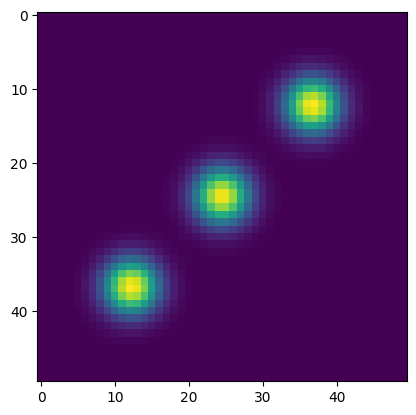

In [2460]:
plt.imshow(torch.atleast_2d(data_probs.probs.squeeze()))
plt.show()

In [2461]:
marg_priors = [MargPrior(latent_grid, prior_var, get_prob_func(num_variables, [i], []))()
               for i in range(num_modalities, num_variables)]
cond_priors = {f"{i - num_modalities}_{j - num_modalities}": CondPrior(
                    latent_grid, prior_var, j - num_modalities, get_prob_func(num_variables, [i, j], [i]))()
               for i in range(num_modalities, num_variables) for j in range(num_modalities, num_variables)
               if i != j}

In [2462]:
encoders = torch.nn.ModuleList(
    [Encoder(data_grid, latent_grid, get_prob_func(num_variables, [modal, num_modalities + modal], [modal])) 
     for modal in range(num_modalities)])
decoders = torch.nn.ModuleList(
    [GaussianDecoder(data_grid, latent_grid, decoder_var, get_prob_func(num_variables, [modal, num_modalities + modal], [num_modalities + modal])) 
     for modal in range(num_modalities)])
# decoders = torch.nn.ModuleList(
#     [UnconstrainedDecoder(data_grid, latent_grid, get_prob_func(num_variables, [modal, num_modalities + modal], [num_modalities + modal])) 
#      for modal in range(num_modalities)])
exact_decoders = torch.nn.ModuleList([ExactDecoder(data_grid, latent_grid, num_modalities, modal) for modal in range(num_modalities)])
mappers = torch.nn.ModuleDict(
    {f"{modal_1}_{modal_2}": Mapper(
        latent_grid, modal_2, get_prob_func(num_variables, [modal_1 + num_modalities, modal_2 + num_modalities], [modal_1 + num_modalities])) 
     for modal_1 in range(num_modalities) for modal_2 in range(num_modalities) if modal_1 != modal_2})
model = torch.nn.ModuleDict({"encoders": encoders, "decoders": decoders, "exact_decoders": exact_decoders, "mappers": mappers})

In [2463]:
steps = 5000000
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)    
for step in range(steps):
    try:
        optimizer.zero_grad()
        encoder_probs = [encoder() for encoder in model["encoders"]]
        decoder_probs = [decoder() for decoder in model["decoders"]]
        mapper_probs = {modal_str: mapper() for (modal_str, mapper) in model["mappers"].items()}
        #loss = ELBO_loss(data_probs, marg_priors, cond_priors, encoder_probs, decoder_probs, mapper_probs)
        loss = MSE_loss(data_grid, data_probs, marg_priors, cond_priors, encoder_probs, exact_decoders, mapper_probs, recon_frac)
        loss.backward()
        optimizer.step()
        print(f"{step + 1}/{steps}: {loss.item():.20f}                  ", end = "\r")
    except KeyboardInterrupt:
        break

In [2464]:
# One modality
# joint_enc_0 = model["encoders"][0]().mul([data_probs])

# Two modalities
joint_enc_0 = model["encoders"][0]().mul([data_probs, model["mappers"]["0_1"]()])
joint_enc_1 = model["encoders"][1]().mul([data_probs, model["mappers"]["1_0"]()])
# joint_dec_0 = model["decoders"][0]().mul([marg_priors[0], cond_priors["0_1"], model["decoders"][1]()])
# joint_dec_1 = model["decoders"][0]().mul([marg_priors[1], cond_priors["1_0"], model["decoders"][1]()])
joint_priors = {key: marg_priors[int(key.split("_")[0])].mul([cond]) for (key, cond) in cond_priors.items()}

## Analysis of two cluster, one modality, MSE

### q(Z_i) vs p_i(Z_i|X_i)

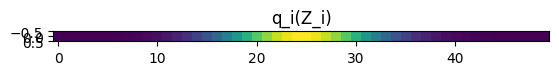

In [1720]:
plt.imshow(marg_priors[0].probs.squeeze()[None].numpy(force = True))
plt.title("q_i(Z_i)")
plt.show()

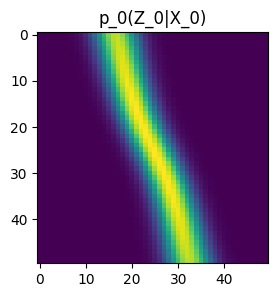

In [1728]:
(fig, axes) = plt.subplots(ncols = 1, figsize = (7, 3))
axes.imshow(model["encoders"][0]().probs.squeeze().numpy(force = True))
axes.set_title("p_0(Z_0|X_0)")
plt.show()

### p_i(Z)

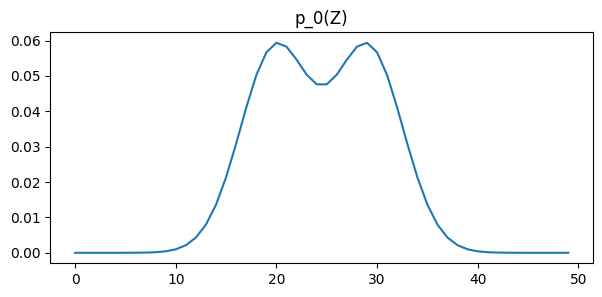

In [1743]:
(fig, axes) = plt.subplots(ncols = 1, figsize = (7, 3))
axes.plot(joint_enc.transform([1]).probs.squeeze().numpy(force = True))
axes.set_title("p_0(Z)")
plt.show()

### Decoder Output

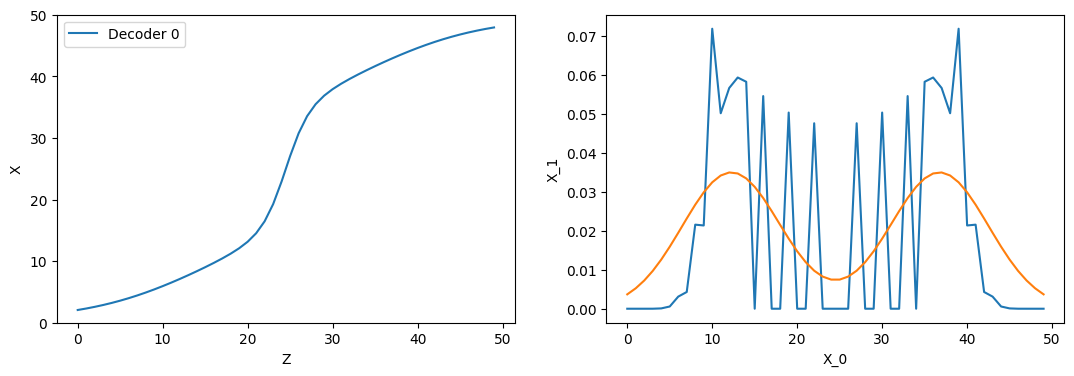

In [1742]:
dec_1 = model["exact_decoders"][0]
out_1 = dec_1.params.squeeze().numpy(force = True)
enc_probs_0 = joint_enc_0.transform([1]).probs.squeeze().numpy(force = True)
flat_grid = data_grid.flatten()
edges = np.concatenate([flat_grid - 0.5*bin_width, flat_grid[-1:] + 0.5*bin_width])
bin_width = flat_grid[1] - flat_grid[0]
hist_0 = np.histogram(out_1, edges, weights = enc_probs_0)[0]

(fig, axes) = plt.subplots(ncols = 2, figsize = (13, 4))
axes[0].plot((out_1 + 3)*50/6)
axes[0].set_xlabel("Z")
axes[0].set_ylabel("X")
axes[0].set_ylim((0, 50))
axes[0].legend(["Decoder 0"])
axes[1].plot(hist_0)
axes[1].plot(data_probs.probs.squeeze().numpy(force = True))
axes[1].set_xlabel("X_0")
axes[1].set_ylabel("X_1")
plt.show()

### Variances

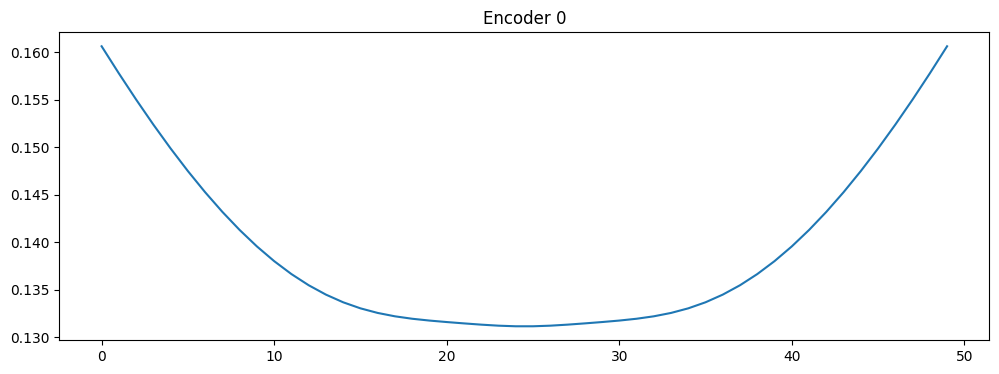

In [1740]:
(fig, axes) = plt.subplots(ncols = 1, figsize = (12, 4))
axes.plot(get_cov(model["encoders"][0].chol).squeeze().numpy(force = True))
axes.set_title("Encoder 0")
plt.show()

## Analysis of two clusters, MSE coupled

### p(Z_j|Z_i) vs q(Z_j|Z_i)

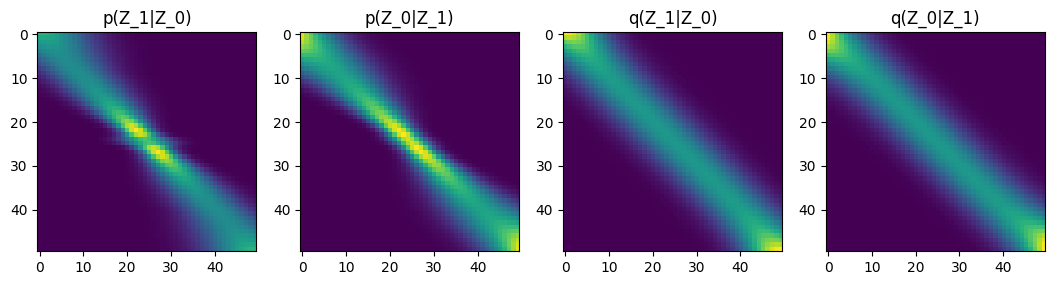

In [2332]:
(fig, axes) = plt.subplots(ncols = 4, figsize = (13, 4))
axes[0].imshow(model["mappers"]["0_1"]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["mappers"]["1_0"]().probs.squeeze().numpy(force = True))
axes[2].imshow(cond_priors["0_1"].probs.squeeze().numpy(force = True))
axes[3].imshow(cond_priors["1_0"].probs.squeeze().numpy(force = True))
axes[0].set_title("p(Z_1|Z_0)")
axes[1].set_title("p(Z_0|Z_1)")
axes[2].set_title("q(Z_1|Z_0)")
axes[3].set_title("q(Z_0|Z_1)")
plt.show()

### q(Z_i) vs p_i(Z_i|X_i)

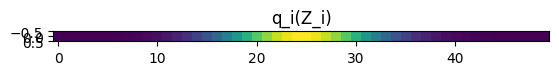

In [1700]:
plt.imshow(marg_priors[0].probs.squeeze()[None].numpy(force = True))
plt.title("q_i(Z_i)")
plt.show()

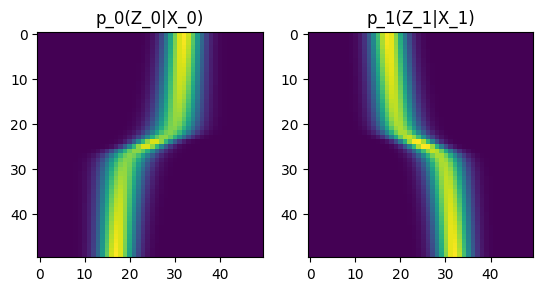

In [2334]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(model["encoders"][0]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["encoders"][1]().probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z_0|X_0)")
axes[1].set_title("p_1(Z_1|X_1)")
plt.show()

### p_i(Z)

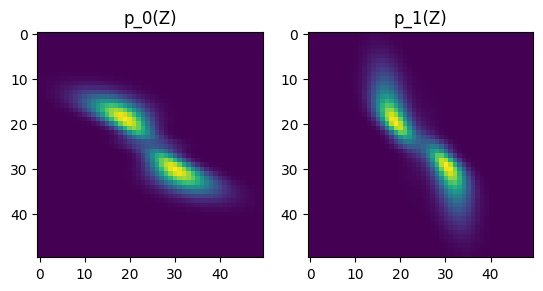

In [2335]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_enc_0.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[1].imshow(joint_enc_1.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z)")
axes[1].set_title("p_1(Z)")
plt.show()

### Decoder Output

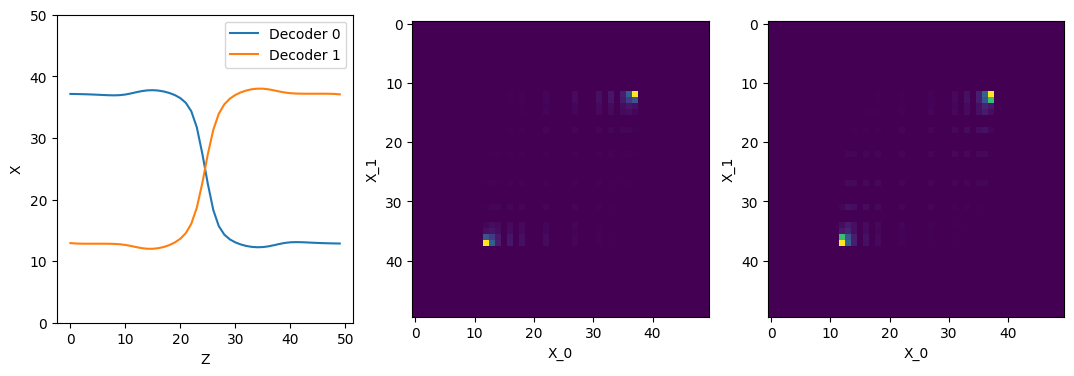

In [2336]:
(dec_1, dec_2) = model["exact_decoders"]
(out_1, out_2) = (dec_1.params.squeeze().numpy(force = True), dec_2.params.squeeze().numpy(force = True))
out_comb = np.stack(np.meshgrid(out_1, out_2, indexing = "ij"), -1).reshape(-1, 2)
enc_probs_0 = joint_enc_0.transform([2, 3]).probs.squeeze().numpy(force = True).flatten()
enc_probs_1 = joint_enc_1.transform([2, 3]).probs.squeeze().numpy(force = True).flatten()
flat_grid = data_grid.flatten()
edges = np.concatenate([flat_grid - 0.5*bin_width, flat_grid[-1:] + 0.5*bin_width])
bin_width = flat_grid[1] - flat_grid[0]
hist_0 = np.histogram2d(out_comb[:, 0], out_comb[:, 1], edges, weights = enc_probs_0)[0]
hist_1 = np.histogram2d(out_comb[:, 0], out_comb[:, 1], edges, weights = enc_probs_1)[0]

(fig, axes) = plt.subplots(ncols = 3, figsize = (13, 4))
axes[0].plot((out_1 + 3)*50/6)
axes[0].set_xlabel("Z")
axes[0].set_ylabel("X")
axes[0].set_ylim((0, 50))
axes[0].plot((out_2 + 3)*50/6)
axes[0].legend(["Decoder 0", "Decoder 1"])
axes[1].imshow(hist_0)
axes[1].set_xlabel("X_0")
axes[1].set_ylabel("X_1")
axes[2].imshow(hist_1)
axes[2].set_xlabel("X_0")
axes[2].set_ylabel("X_1")
plt.show()

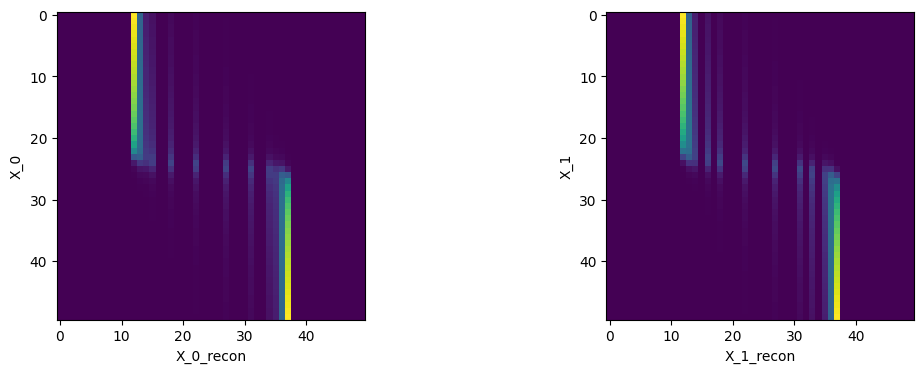

In [2337]:
(dec_1, dec_2) = model["exact_decoders"]
(out_1, out_2) = (dec_1.params.squeeze().numpy(force = True), dec_2.params.squeeze().numpy(force = True))
enc_probs_0 = joint_enc_0.transform([2], [0]).probs.squeeze().numpy(force = True)
enc_probs_1 = joint_enc_1.transform([3], [1]).probs.squeeze().numpy(force = True)
flat_grid = data_grid.flatten()
edges = np.concatenate([flat_grid - 0.5*bin_width, flat_grid[-1:] + 0.5*bin_width])
bin_width = flat_grid[1] - flat_grid[0]
hist_0 = [np.histogram(out_1, edges, weights = probs)[0] for probs in enc_probs_0]
hist_1 = [np.histogram(out_2, edges, weights = probs)[0] for probs in enc_probs_1]

(fig, axes) = plt.subplots(ncols = 2, figsize = (13, 4))
axes[0].imshow(hist_0)
axes[0].set_xlabel("X_0_recon")
axes[0].set_ylabel("X_0")
axes[1].imshow(hist_1)
axes[1].set_xlabel("X_1_recon")
axes[1].set_ylabel("X_1")
plt.show()

### Variances

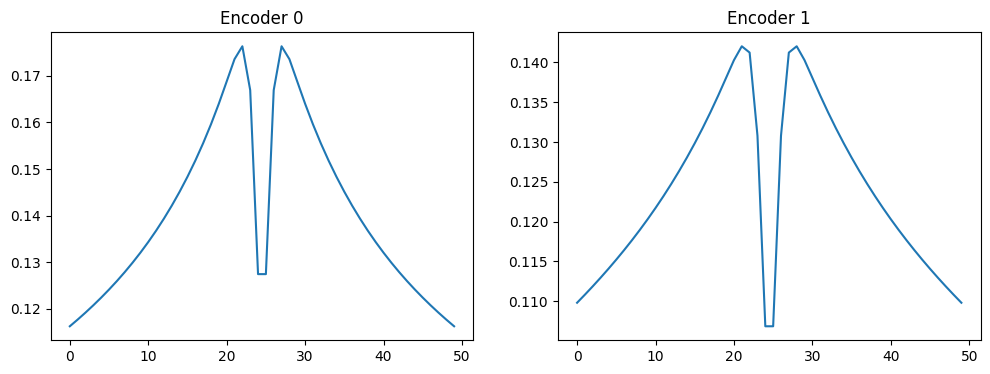

In [2338]:
(fig, axes) = plt.subplots(ncols = 2, figsize = (12, 4))
axes[0].plot(get_cov(model["encoders"][0].chol).squeeze().numpy(force = True))
axes[1].plot(get_cov(model["encoders"][1].chol).squeeze().numpy(force = True))
axes[0].set_title("Encoder 0")
axes[1].set_title("Encoder 1")
plt.show()

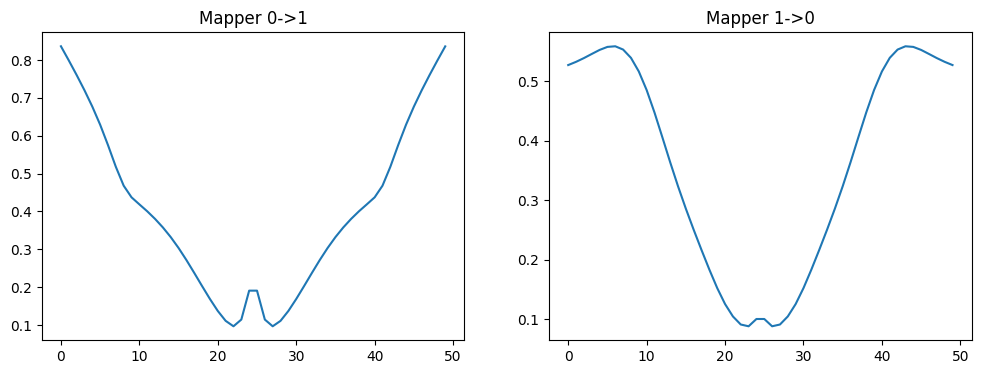

In [2339]:
(fig, axes) = plt.subplots(ncols = 2, figsize = (12, 4))
axes[0].plot(get_cov(model["mappers"]["0_1"].chol).squeeze().numpy(force = True))
axes[1].plot(get_cov(model["mappers"]["1_0"].chol).squeeze().numpy(force = True))
axes[0].set_title("Mapper 0->1")
axes[1].set_title("Mapper 1->0")
plt.show()

## Analysis of three clusters, MSE

### p(Z_j|Z_i) vs q(Z_j|Z_i)

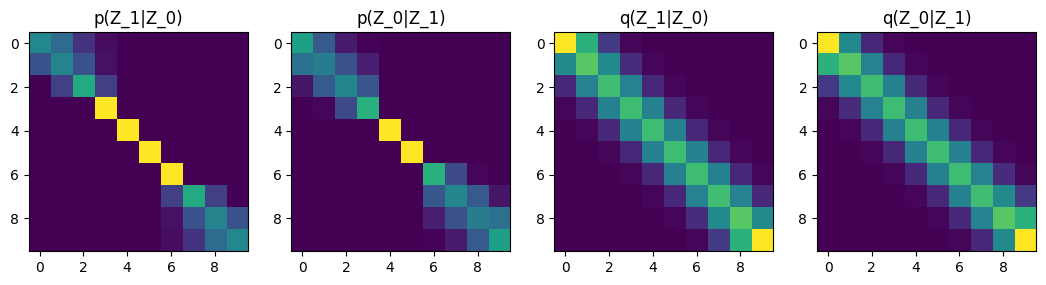

In [2465]:
(fig, axes) = plt.subplots(ncols = 4, figsize = (13, 4))
axes[0].imshow(model["mappers"]["0_1"]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["mappers"]["1_0"]().probs.squeeze().numpy(force = True))
axes[2].imshow(cond_priors["0_1"].probs.squeeze().numpy(force = True))
axes[3].imshow(cond_priors["1_0"].probs.squeeze().numpy(force = True))
axes[0].set_title("p(Z_1|Z_0)")
axes[1].set_title("p(Z_0|Z_1)")
axes[2].set_title("q(Z_1|Z_0)")
axes[3].set_title("q(Z_0|Z_1)")
plt.show()

### q(Z_i) vs p_i(Z_i|X_i)

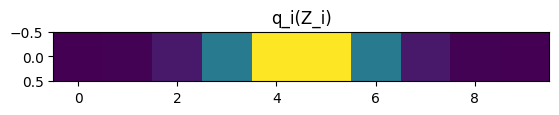

In [2466]:
plt.imshow(marg_priors[0].probs.squeeze()[None].numpy(force = True))
plt.title("q_i(Z_i)")
plt.show()

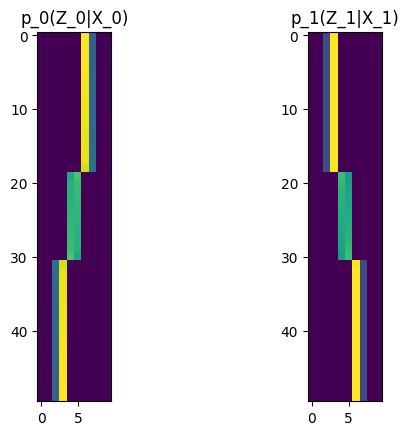

In [2467]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(model["encoders"][0]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["encoders"][1]().probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z_0|X_0)")
axes[1].set_title("p_1(Z_1|X_1)")
plt.show()

### p_i(Z)

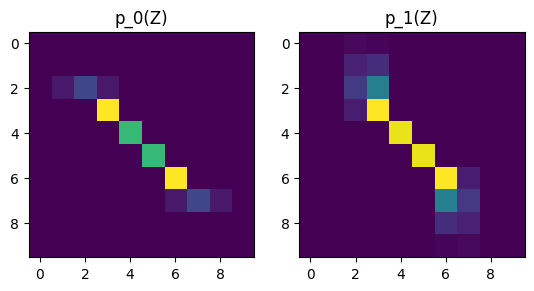

In [2468]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_enc_0.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[1].imshow(joint_enc_1.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z)")
axes[1].set_title("p_1(Z)")
plt.show()

### Decoder Output

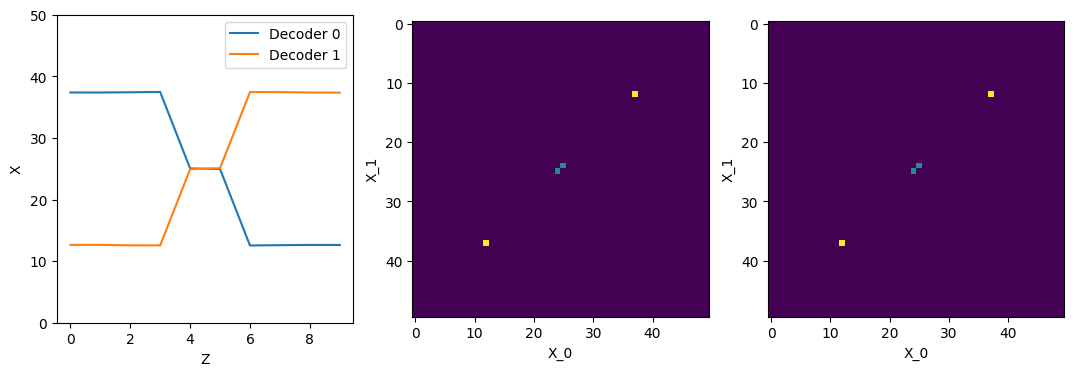

In [2469]:
(dec_1, dec_2) = model["exact_decoders"]
(out_1, out_2) = (dec_1.params.squeeze().numpy(force = True), dec_2.params.squeeze().numpy(force = True))
out_comb = np.stack(np.meshgrid(out_1, out_2, indexing = "ij"), -1).reshape(-1, 2)
enc_probs_0 = joint_enc_0.transform([2, 3]).probs.squeeze().numpy(force = True).flatten()
enc_probs_1 = joint_enc_1.transform([2, 3]).probs.squeeze().numpy(force = True).flatten()
flat_grid = data_grid.flatten()
edges = np.concatenate([flat_grid - 0.5*bin_width, flat_grid[-1:] + 0.5*bin_width])
bin_width = flat_grid[1] - flat_grid[0]
hist_0 = np.histogram2d(out_comb[:, 0], out_comb[:, 1], edges, weights = enc_probs_0)[0]
hist_1 = np.histogram2d(out_comb[:, 0], out_comb[:, 1], edges, weights = enc_probs_1)[0]

(fig, axes) = plt.subplots(ncols = 3, figsize = (13, 4))
axes[0].plot((out_1 + 3)*50/6)
axes[0].set_xlabel("Z")
axes[0].set_ylabel("X")
axes[0].set_ylim((0, 50))
axes[0].plot((out_2 + 3)*50/6)
axes[0].legend(["Decoder 0", "Decoder 1"])
axes[1].imshow(hist_0)
axes[1].set_xlabel("X_0")
axes[1].set_ylabel("X_1")
axes[2].imshow(hist_1)
axes[2].set_xlabel("X_0")
axes[2].set_ylabel("X_1")
plt.show()

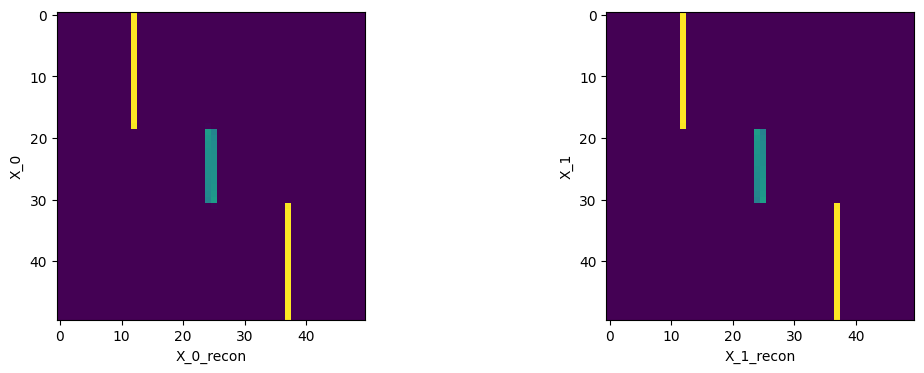

In [2470]:
(dec_1, dec_2) = model["exact_decoders"]
(out_1, out_2) = (dec_1.params.squeeze().numpy(force = True), dec_2.params.squeeze().numpy(force = True))
enc_probs_0 = joint_enc_0.transform([2], [0]).probs.squeeze().numpy(force = True)
enc_probs_1 = joint_enc_1.transform([3], [1]).probs.squeeze().numpy(force = True)
flat_grid = data_grid.flatten()
edges = np.concatenate([flat_grid - 0.5*bin_width, flat_grid[-1:] + 0.5*bin_width])
bin_width = flat_grid[1] - flat_grid[0]
hist_0 = [np.histogram(out_1, edges, weights = probs)[0] for probs in enc_probs_0]
hist_1 = [np.histogram(out_2, edges, weights = probs)[0] for probs in enc_probs_1]

(fig, axes) = plt.subplots(ncols = 2, figsize = (13, 4))
axes[0].imshow(hist_0)
axes[0].set_xlabel("X_0_recon")
axes[0].set_ylabel("X_0")
axes[1].imshow(hist_1)
axes[1].set_xlabel("X_1_recon")
axes[1].set_ylabel("X_1")
plt.show()

### Variances

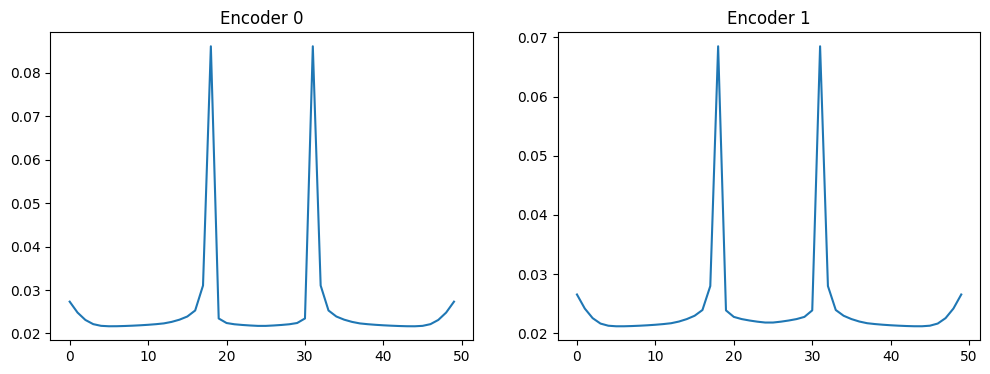

In [2471]:
(fig, axes) = plt.subplots(ncols = 2, figsize = (12, 4))
axes[0].plot(get_cov(model["encoders"][0].chol).squeeze().numpy(force = True))
axes[1].plot(get_cov(model["encoders"][1].chol).squeeze().numpy(force = True))
axes[0].set_title("Encoder 0")
axes[1].set_title("Encoder 1")
plt.show()

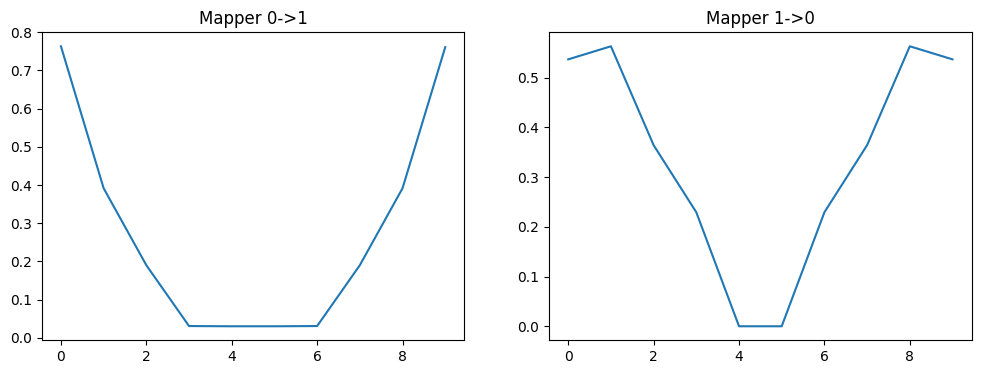

In [2472]:
(fig, axes) = plt.subplots(ncols = 2, figsize = (12, 4))
axes[0].plot(get_cov(model["mappers"]["0_1"].chol).squeeze().numpy(force = True))
axes[1].plot(get_cov(model["mappers"]["1_0"].chol).squeeze().numpy(force = True))
axes[0].set_title("Mapper 0->1")
axes[1].set_title("Mapper 1->0")
plt.show()

## Analysis of two clusters, MSE uncoupled

### p(Z_j|Z_i) vs q(Z_j|Z_i)

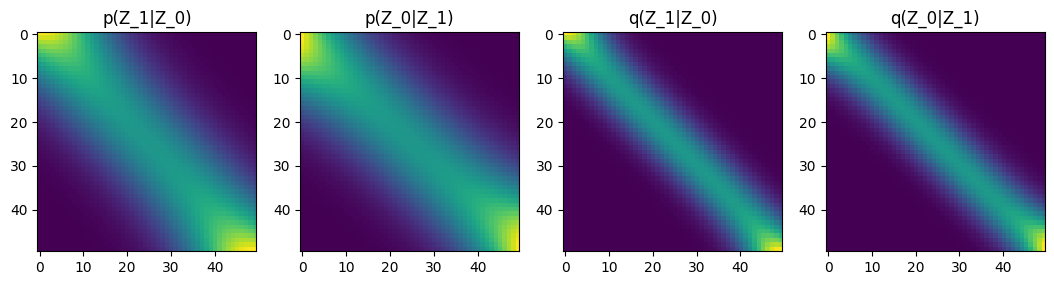

In [2200]:
(fig, axes) = plt.subplots(ncols = 4, figsize = (13, 4))
axes[0].imshow(model["mappers"]["0_1"]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["mappers"]["1_0"]().probs.squeeze().numpy(force = True))
axes[2].imshow(cond_priors["0_1"].probs.squeeze().numpy(force = True))
axes[3].imshow(cond_priors["1_0"].probs.squeeze().numpy(force = True))
axes[0].set_title("p(Z_1|Z_0)")
axes[1].set_title("p(Z_0|Z_1)")
axes[2].set_title("q(Z_1|Z_0)")
axes[3].set_title("q(Z_0|Z_1)")
plt.show()

### q(Z_i) vs p_i(Z_i|X_i)

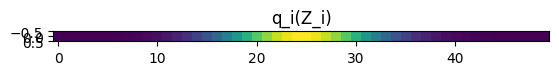

In [1700]:
plt.imshow(marg_priors[0].probs.squeeze()[None].numpy(force = True))
plt.title("q_i(Z_i)")
plt.show()

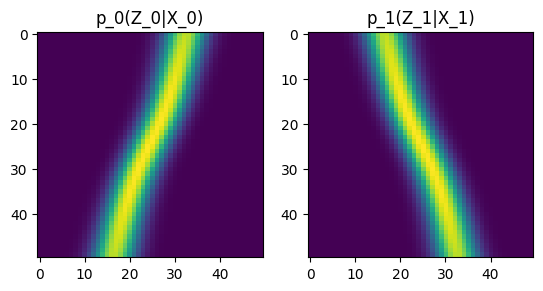

In [2201]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(model["encoders"][0]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["encoders"][1]().probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z_0|X_0)")
axes[1].set_title("p_1(Z_1|X_1)")
plt.show()

### p_i(Z)

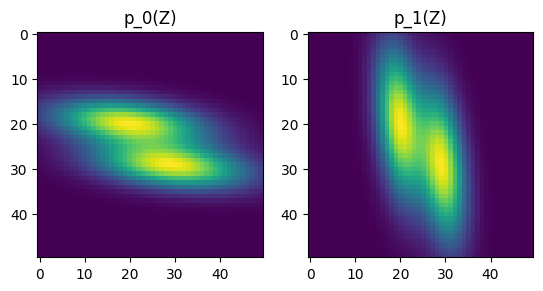

In [2202]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_enc_0.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[1].imshow(joint_enc_1.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z)")
axes[1].set_title("p_1(Z)")
plt.show()

### Decoder Output

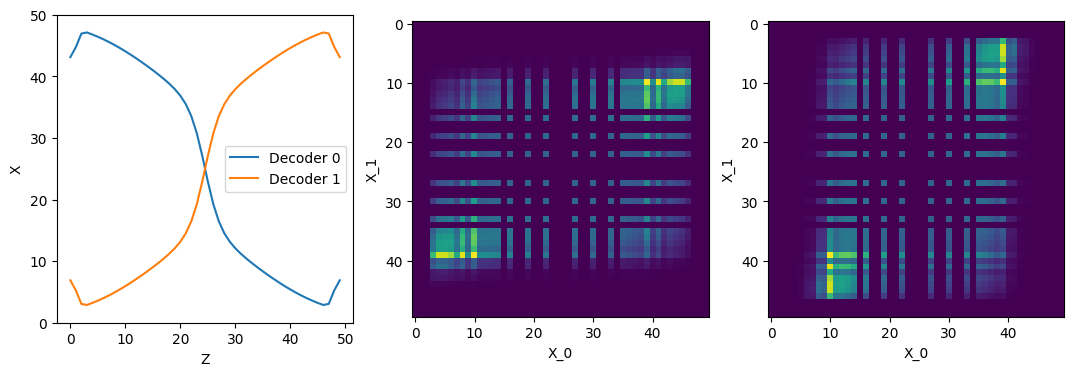

In [2203]:
(dec_1, dec_2) = model["exact_decoders"]
(out_1, out_2) = (dec_1.params.squeeze().numpy(force = True), dec_2.params.squeeze().numpy(force = True))
out_comb = np.stack(np.meshgrid(out_1, out_2, indexing = "ij"), -1).reshape(-1, 2)
enc_probs_0 = joint_enc_0.transform([2, 3]).probs.squeeze().numpy(force = True).flatten()
enc_probs_1 = joint_enc_1.transform([2, 3]).probs.squeeze().numpy(force = True).flatten()
flat_grid = data_grid.flatten()
edges = np.concatenate([flat_grid - 0.5*bin_width, flat_grid[-1:] + 0.5*bin_width])
bin_width = flat_grid[1] - flat_grid[0]
hist_0 = np.histogram2d(out_comb[:, 0], out_comb[:, 1], edges, weights = enc_probs_0)[0]
hist_1 = np.histogram2d(out_comb[:, 0], out_comb[:, 1], edges, weights = enc_probs_1)[0]

(fig, axes) = plt.subplots(ncols = 3, figsize = (13, 4))
axes[0].plot((out_1 + 3)*50/6)
axes[0].set_xlabel("Z")
axes[0].set_ylabel("X")
axes[0].set_ylim((0, 50))
axes[0].plot((out_2 + 3)*50/6)
axes[0].legend(["Decoder 0", "Decoder 1"])
axes[1].imshow(hist_0)
axes[1].set_xlabel("X_0")
axes[1].set_ylabel("X_1")
axes[2].imshow(hist_1)
axes[2].set_xlabel("X_0")
axes[2].set_ylabel("X_1")
plt.show()

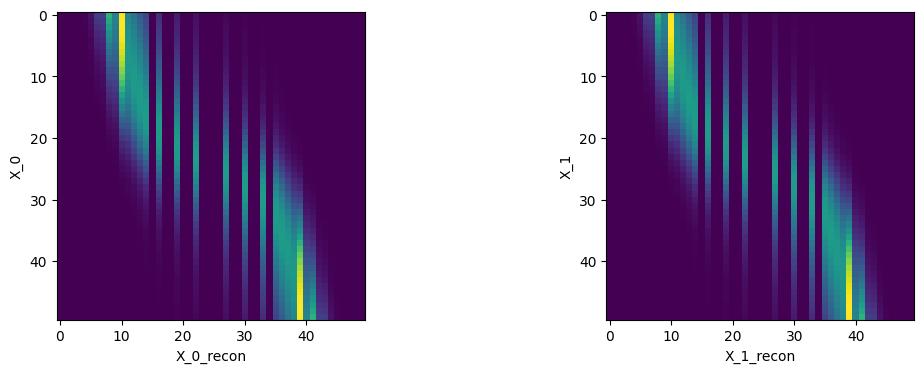

In [2204]:
(dec_1, dec_2) = model["exact_decoders"]
(out_1, out_2) = (dec_1.params.squeeze().numpy(force = True), dec_2.params.squeeze().numpy(force = True))
enc_probs_0 = joint_enc_0.transform([2], [0]).probs.squeeze().numpy(force = True)
enc_probs_1 = joint_enc_1.transform([3], [1]).probs.squeeze().numpy(force = True)
flat_grid = data_grid.flatten()
edges = np.concatenate([flat_grid - 0.5*bin_width, flat_grid[-1:] + 0.5*bin_width])
bin_width = flat_grid[1] - flat_grid[0]
hist_0 = [np.histogram(out_1, edges, weights = probs)[0] for probs in enc_probs_0]
hist_1 = [np.histogram(out_2, edges, weights = probs)[0] for probs in enc_probs_1]

(fig, axes) = plt.subplots(ncols = 2, figsize = (13, 4))
axes[0].imshow(hist_0)
axes[0].set_xlabel("X_0_recon")
axes[0].set_ylabel("X_0")
axes[1].imshow(hist_1)
axes[1].set_xlabel("X_1_recon")
axes[1].set_ylabel("X_1")
plt.show()

### Variances

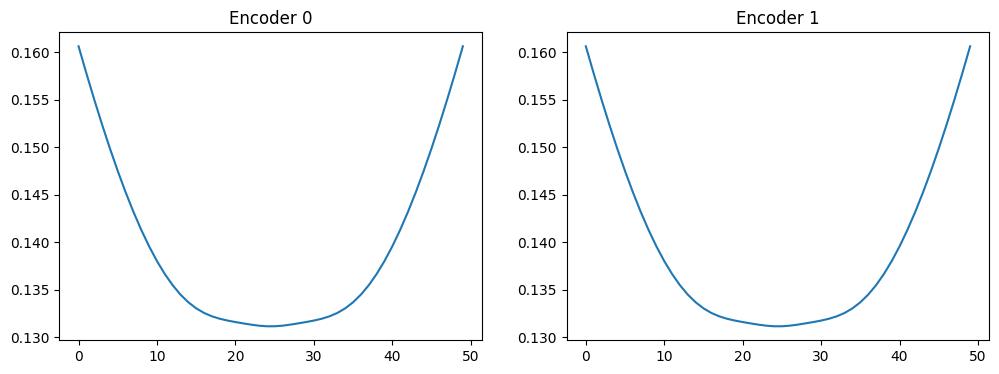

In [2205]:
(fig, axes) = plt.subplots(ncols = 2, figsize = (12, 4))
axes[0].plot(get_cov(model["encoders"][0].chol).squeeze().numpy(force = True))
axes[1].plot(get_cov(model["encoders"][1].chol).squeeze().numpy(force = True))
axes[0].set_title("Encoder 0")
axes[1].set_title("Encoder 1")
plt.show()

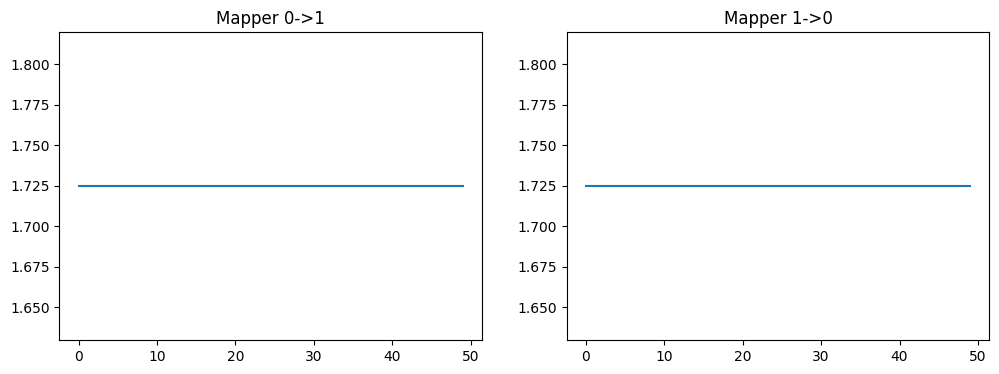

In [2207]:
(fig, axes) = plt.subplots(ncols = 2, figsize = (12, 4))
axes[0].plot(get_cov(model["mappers"]["0_1"].chol).squeeze().numpy(force = True))
axes[1].plot(get_cov(model["mappers"]["1_0"].chol).squeeze().numpy(force = True))
axes[0].set_title("Mapper 0->1")
axes[1].set_title("Mapper 1->0")
plt.show()

## Analysis of two clusters, MSE without regularization

### p(Z_j|Z_i) vs q(Z_j|Z_i)

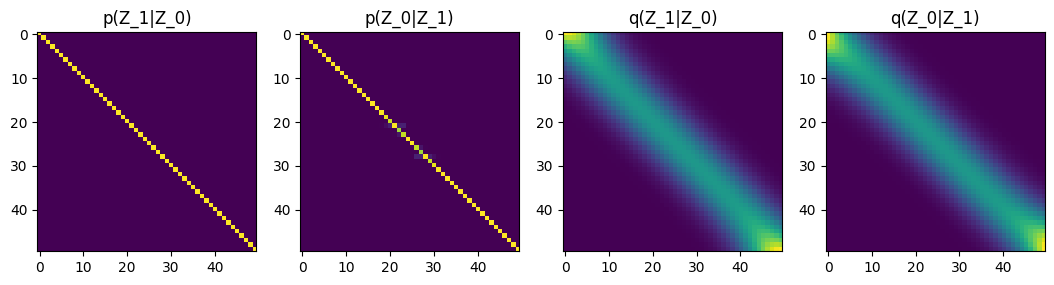

In [1665]:
(fig, axes) = plt.subplots(ncols = 4, figsize = (13, 4))
axes[0].imshow(model["mappers"]["0_1"]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["mappers"]["1_0"]().probs.squeeze().numpy(force = True))
axes[2].imshow(cond_priors["0_1"].probs.squeeze().numpy(force = True))
axes[3].imshow(cond_priors["1_0"].probs.squeeze().numpy(force = True))
axes[0].set_title("p(Z_1|Z_0)")
axes[1].set_title("p(Z_0|Z_1)")
axes[2].set_title("q(Z_1|Z_0)")
axes[3].set_title("q(Z_0|Z_1)")
plt.show()

### q(Z_i) vs p_i(Z_i|X_i)

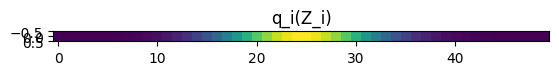

In [1666]:
plt.imshow(marg_priors[0].probs.squeeze()[None].numpy(force = True))
plt.title("q_i(Z_i)")
plt.show()

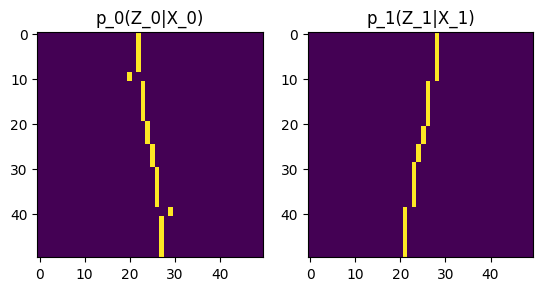

In [1667]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(model["encoders"][0]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["encoders"][1]().probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z_0|X_0)")
axes[1].set_title("p_1(Z_1|X_1)")
plt.show()

### p_i(Z)

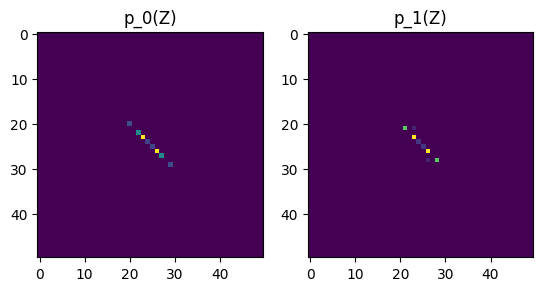

In [1668]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_enc_0.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[1].imshow(joint_enc_1.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z)")
axes[1].set_title("p_1(Z)")
plt.show()

### Decoder Output

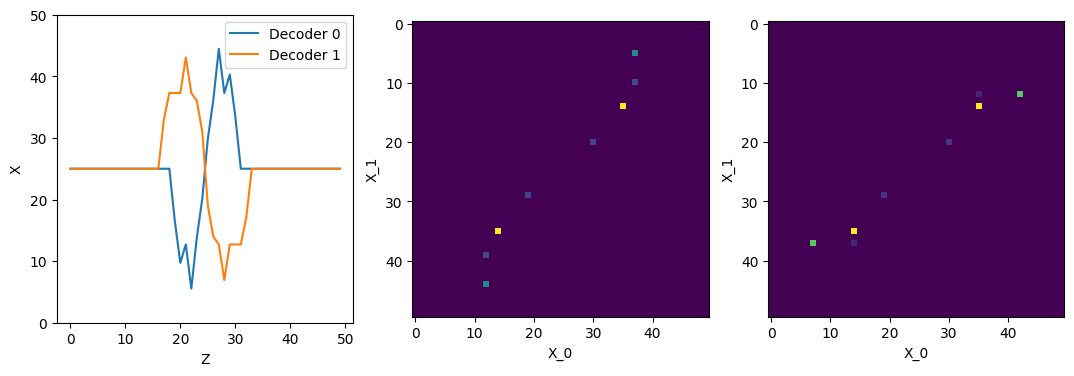

In [1690]:
(dec_1, dec_2) = model["exact_decoders"]
(out_1, out_2) = (dec_1.params.squeeze().numpy(force = True), dec_2.params.squeeze().numpy(force = True))
out_comb = np.stack(np.meshgrid(out_1, out_2, indexing = "ij"), -1).reshape(-1, 2)
enc_probs_0 = joint_enc_0.transform([2, 3]).probs.squeeze().numpy(force = True).flatten()
enc_probs_1 = joint_enc_1.transform([2, 3]).probs.squeeze().numpy(force = True).flatten()
flat_grid = data_grid.flatten()
edges = np.concatenate([flat_grid - 0.5*bin_width, flat_grid[-1:] + 0.5*bin_width])
bin_width = flat_grid[1] - flat_grid[0]
hist_0 = np.histogram2d(out_comb[:, 0], out_comb[:, 1], edges, weights = enc_probs_0)[0]
hist_1 = np.histogram2d(out_comb[:, 0], out_comb[:, 1], edges, weights = enc_probs_1)[0]

(fig, axes) = plt.subplots(ncols = 3, figsize = (13, 4))
axes[0].plot((out_1 + 3)*50/6)
axes[0].set_xlabel("Z")
axes[0].set_ylabel("X")
axes[0].set_ylim((0, 50))
axes[0].plot((out_2 + 3)*50/6)
axes[0].legend(["Decoder 0", "Decoder 1"])
axes[1].imshow(hist_0)
axes[1].set_xlabel("X_0")
axes[1].set_ylabel("X_1")
axes[2].imshow(hist_1)
axes[2].set_xlabel("X_0")
axes[2].set_ylabel("X_1")
plt.show()

### Variances

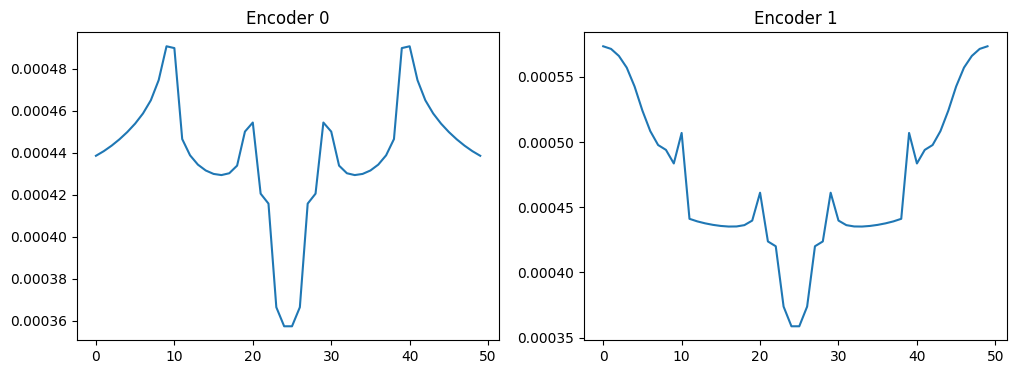

In [1674]:
(fig, axes) = plt.subplots(ncols = 2, figsize = (12, 4))
axes[0].plot(get_cov(model["encoders"][0].chol).squeeze().numpy(force = True))
axes[1].plot(get_cov(model["encoders"][1].chol).squeeze().numpy(force = True))
axes[0].set_title("Encoder 0")
axes[1].set_title("Encoder 1")
plt.show()

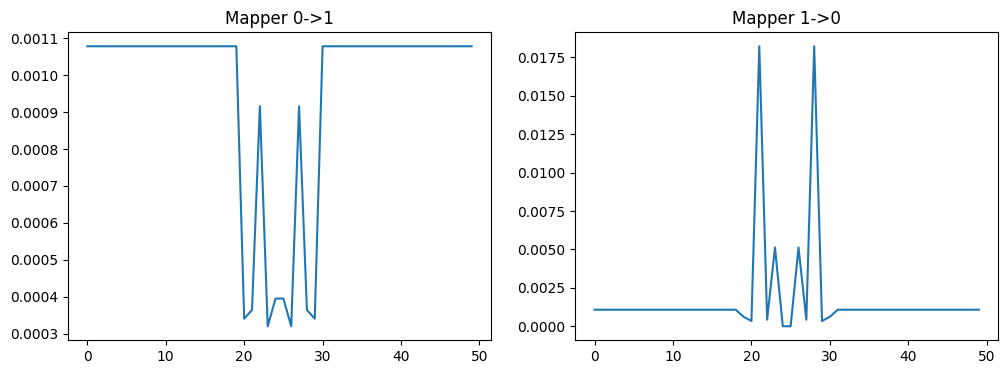

In [1675]:
(fig, axes) = plt.subplots(ncols = 2, figsize = (12, 4))
axes[0].plot(get_cov(model["mappers"]["0_1"].chol).squeeze().numpy(force = True))
axes[1].plot(get_cov(model["mappers"]["1_0"].chol).squeeze().numpy(force = True))
axes[0].set_title("Mapper 0->1")
axes[1].set_title("Mapper 1->0")
plt.show()

## Analysis of two clusters, unconstrained decoder

### p(X) vs q_i(X)

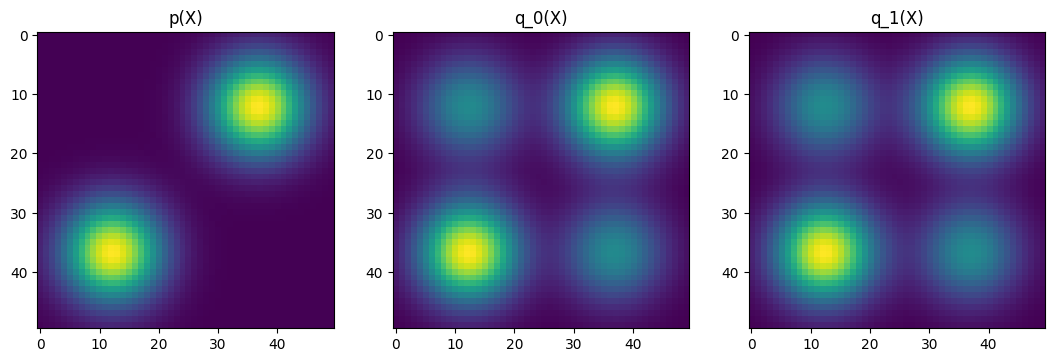

In [1341]:
(fig, axes) = plt.subplots(ncols = 3, figsize = (13, 4))
axes[0].imshow(joint_enc.transform([0, 1]).probs.squeeze().numpy(force = True))
axes[1].imshow(joint_dec_0.transform([0, 1]).probs.squeeze().numpy(force = True))
axes[2].imshow(joint_dec_1.transform([0, 1]).probs.squeeze().numpy(force = True))
axes[0].set_title("p(X)")
axes[1].set_title("q_0(X)")
axes[2].set_title("q_1(X)")
plt.show()

### p_i(Z|X_i) vs q_i(Z|X)

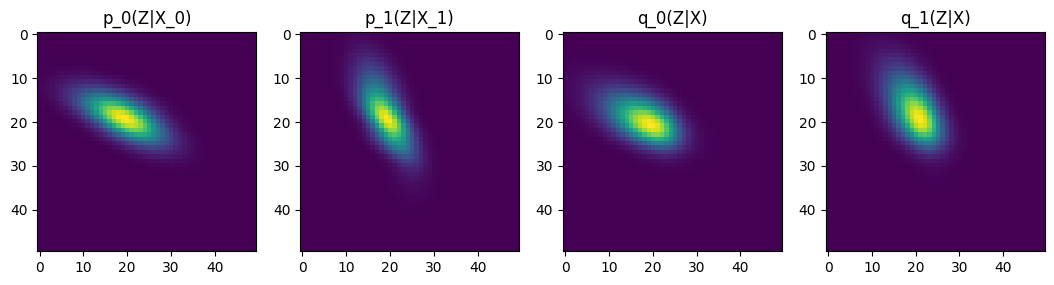

In [1342]:
pos = (35, 12)
(fig, axes) = plt.subplots(ncols = 4, figsize = (13, 4))
axes[0].imshow(joint_enc_0.transform([2, 3], [0]).probs[pos[0]].squeeze().numpy(force = True))
axes[1].imshow(joint_enc_1.transform([2, 3], [1]).probs[:, pos[1]].squeeze().numpy(force = True))
axes[2].imshow(joint_dec_0.probs[pos].squeeze().numpy(force = True))
axes[3].imshow(joint_dec_1.probs[pos].squeeze().numpy(force = True))
axes[0].set_title("p_0(Z|X_0)")
axes[1].set_title("p_1(Z|X_1)")
axes[2].set_title("q_0(Z|X)")
axes[3].set_title("q_1(Z|X)")
plt.show()

### p(Z_j|Z_i) vs q(Z_j|Z_i)

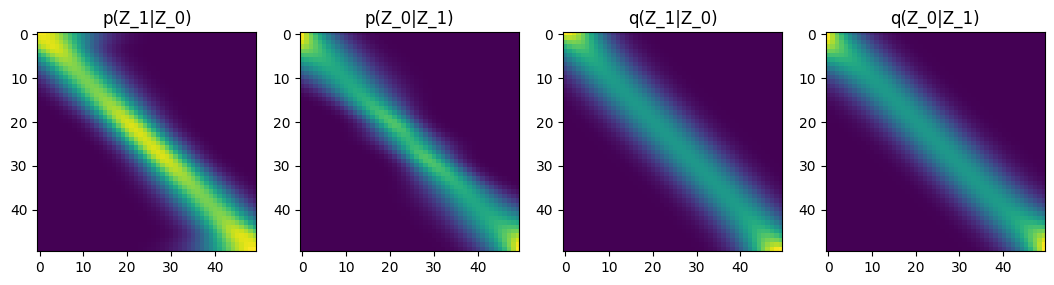

In [1343]:
(fig, axes) = plt.subplots(ncols = 4, figsize = (13, 4))
axes[0].imshow(model["mappers"]["0_1"]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["mappers"]["1_0"]().probs.squeeze().numpy(force = True))
axes[2].imshow(cond_priors["0_1"].probs.squeeze().numpy(force = True))
axes[3].imshow(cond_priors["1_0"].probs.squeeze().numpy(force = True))
axes[0].set_title("p(Z_1|Z_0)")
axes[1].set_title("p(Z_0|Z_1)")
axes[2].set_title("q(Z_1|Z_0)")
axes[3].set_title("q(Z_0|Z_1)")
plt.show()

### q(Z_i) vs p_i(Z_i|X_i)

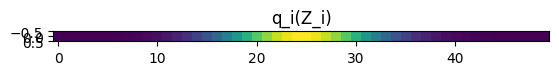

In [1344]:
plt.imshow(marg_priors[0].probs.squeeze()[None].numpy(force = True))
plt.title("q_i(Z_i)")
plt.show()

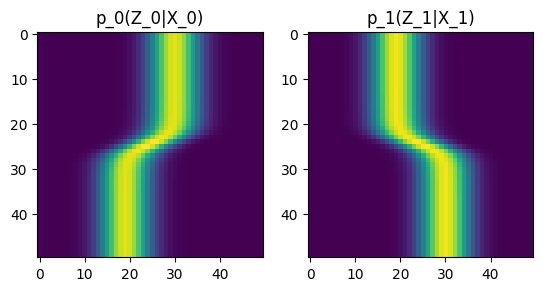

In [1345]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(model["encoders"][0]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["encoders"][1]().probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z_0|X_0)")
axes[1].set_title("p_1(Z_1|X_1)")
plt.show()

### p_i(Z) and q_i(X|Z)

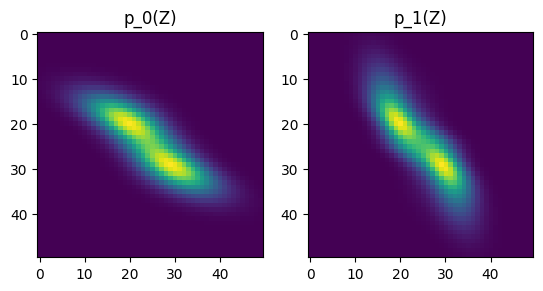

In [1346]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_enc_0.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[1].imshow(joint_enc_1.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z)")
axes[1].set_title("p_1(Z)")
plt.show()

#### Cluster 0

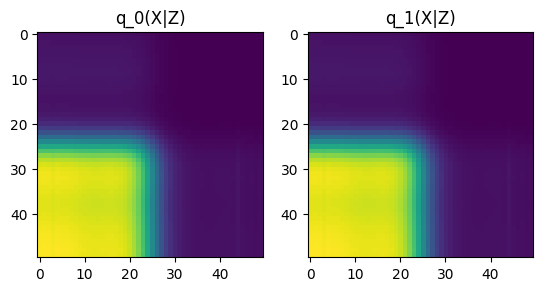

In [1347]:
latent_pos = (20, 20)
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_dec_0.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[1].imshow(joint_dec_1.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[0].set_title("q_0(X|Z)")
axes[1].set_title("q_1(X|Z)")
plt.show()

#### Cluster 1

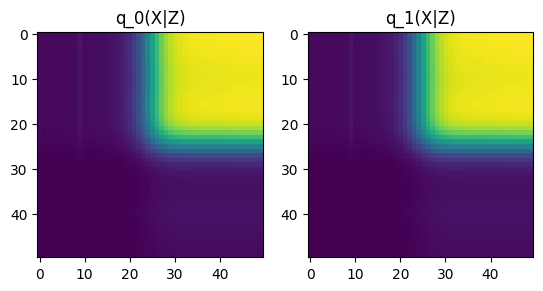

In [1348]:
latent_pos = (30, 30)
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_dec_0.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[1].imshow(joint_dec_1.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[0].set_title("q_0(X|Z)")
axes[1].set_title("q_1(X|Z)")
plt.show()

#### Intermediate

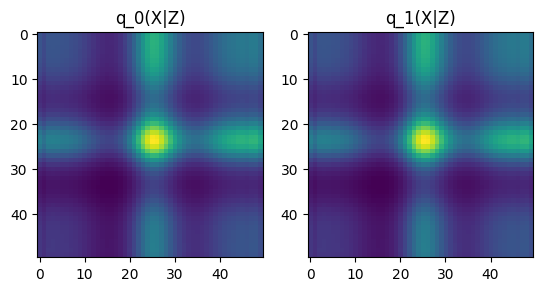

In [1349]:
latent_pos = (25, 25)
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_dec_0.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[1].imshow(joint_dec_1.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[0].set_title("q_0(X|Z)")
axes[1].set_title("q_1(X|Z)")
plt.show()

### p(X_j|X_i) vs q(X_j|X_i) vs int_Z q(X_j|Z)p(Z|X_i)

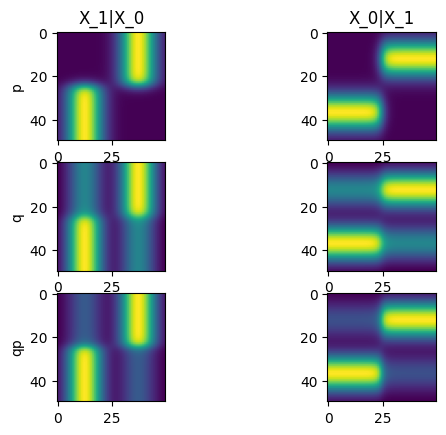

In [1350]:
(fig, (axes_1, axes_2, axes_3)) = plt.subplots(nrows = 3, ncols = 2)
axes_1[0].imshow(data_probs.transform([1], [0]).probs.squeeze().numpy(force = True))
axes_1[1].imshow(data_probs.transform([0], [1]).probs.squeeze().numpy(force = True))
axes_2[0].imshow(joint_dec_0.transform([1], [0]).probs.squeeze().numpy(force = True))
axes_2[1].imshow(joint_dec_1.transform([0], [1]).probs.squeeze().numpy(force = True))
axes_3[0].imshow(joint_enc_0.transform([2, 3], [0, 1]).average(joint_dec_0.transform([1], [2, 3]).probs).squeeze().numpy(force = True))
axes_3[1].imshow(joint_enc_1.transform([2, 3], [0, 1]).average(joint_dec_1.transform([0], [2, 3]).probs).squeeze().numpy(force = True))
axes_1[0].set_title("X_1|X_0")
axes_1[1].set_title("X_0|X_1")
axes_1[0].set_ylabel("p")
axes_2[0].set_ylabel("q")
axes_3[0].set_ylabel("qp")
plt.show()

## Analysis of three cluster triangle, unconstrained decoder

### p(X) vs q_i(X)

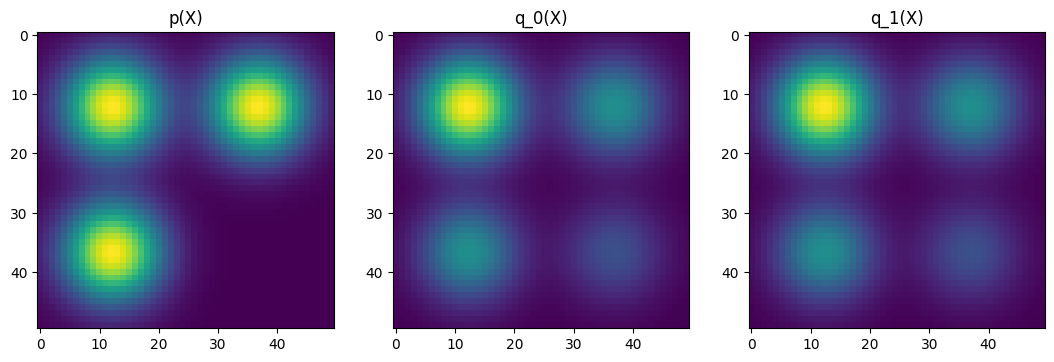

In [1374]:
(fig, axes) = plt.subplots(ncols = 3, figsize = (13, 4))
axes[0].imshow(data_probs.transform([0, 1]).probs.squeeze().numpy(force = True))
axes[1].imshow(joint_dec_0.transform([0, 1]).probs.squeeze().numpy(force = True))
axes[2].imshow(joint_dec_1.transform([0, 1]).probs.squeeze().numpy(force = True))
axes[0].set_title("p(X)")
axes[1].set_title("q_0(X)")
axes[2].set_title("q_1(X)")
plt.show()

### p_i(Z|X_i) vs q_i(Z|X)

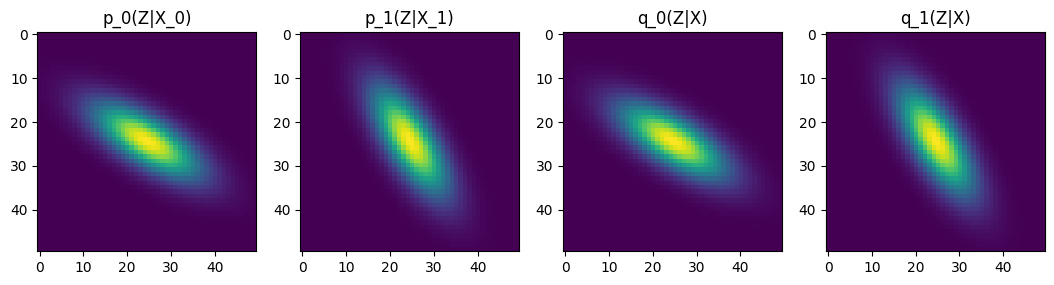

In [1375]:
pos = (35, 12)
(fig, axes) = plt.subplots(ncols = 4, figsize = (13, 4))
axes[0].imshow(joint_enc_0.transform([2, 3], [0]).probs[pos[0]].squeeze().numpy(force = True))
axes[1].imshow(joint_enc_1.transform([2, 3], [1]).probs[:, pos[1]].squeeze().numpy(force = True))
axes[2].imshow(joint_dec_0.probs[pos].squeeze().numpy(force = True))
axes[3].imshow(joint_dec_1.probs[pos].squeeze().numpy(force = True))
axes[0].set_title("p_0(Z|X_0)")
axes[1].set_title("p_1(Z|X_1)")
axes[2].set_title("q_0(Z|X)")
axes[3].set_title("q_1(Z|X)")
plt.show()

### p(Z_j|Z_i) vs q(Z_j|Z_i)

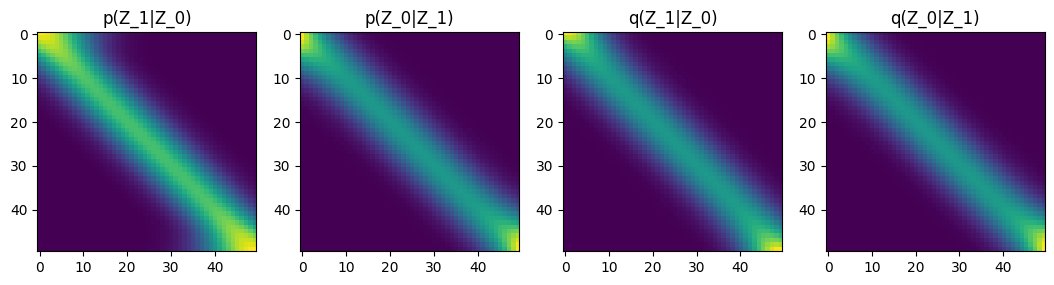

In [1376]:
(fig, axes) = plt.subplots(ncols = 4, figsize = (13, 4))
axes[0].imshow(model["mappers"]["0_1"]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["mappers"]["1_0"]().probs.squeeze().numpy(force = True))
axes[2].imshow(cond_priors["0_1"].probs.squeeze().numpy(force = True))
axes[3].imshow(cond_priors["1_0"].probs.squeeze().numpy(force = True))
axes[0].set_title("p(Z_1|Z_0)")
axes[1].set_title("p(Z_0|Z_1)")
axes[2].set_title("q(Z_1|Z_0)")
axes[3].set_title("q(Z_0|Z_1)")
plt.show()

### q(Z_i) vs p_i(Z_i|X_i)

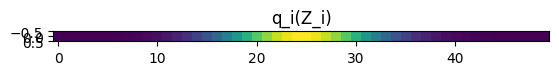

In [1377]:
plt.imshow(marg_priors[0].probs.squeeze()[None].numpy(force = True))
plt.title("q_i(Z_i)")
plt.show()

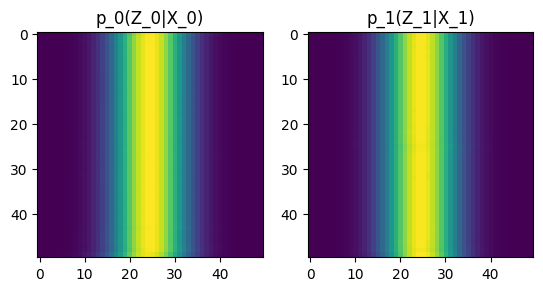

In [1378]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(model["encoders"][0]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["encoders"][1]().probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z_0|X_0)")
axes[1].set_title("p_1(Z_1|X_1)")
plt.show()

### p_i(Z) and q_i(X|Z)

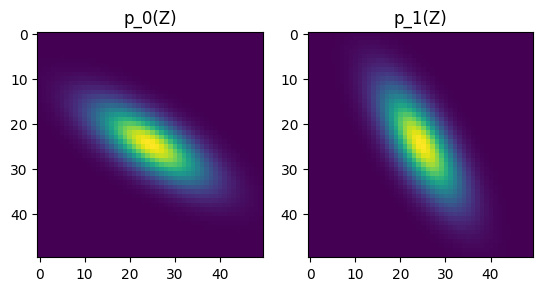

In [1379]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_enc_0.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[1].imshow(joint_enc_1.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z)")
axes[1].set_title("p_1(Z)")
plt.show()

#### Cluster 0

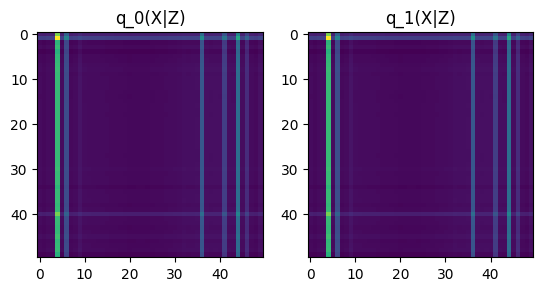

In [1381]:
latent_pos = (25, 25)
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_dec_0.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[1].imshow(joint_dec_1.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[0].set_title("q_0(X|Z)")
axes[1].set_title("q_1(X|Z)")
plt.show()

### p(X_j|X_i) vs q(X_j|X_i) vs int_Z q(X_j|Z)p(Z|X_i)

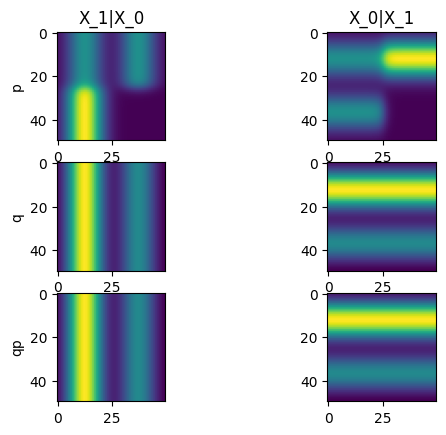

In [1382]:
(fig, (axes_1, axes_2, axes_3)) = plt.subplots(nrows = 3, ncols = 2)
axes_1[0].imshow(data_probs.transform([1], [0]).probs.squeeze().numpy(force = True))
axes_1[1].imshow(data_probs.transform([0], [1]).probs.squeeze().numpy(force = True))
axes_2[0].imshow(joint_dec_0.transform([1], [0]).probs.squeeze().numpy(force = True))
axes_2[1].imshow(joint_dec_1.transform([0], [1]).probs.squeeze().numpy(force = True))
axes_3[0].imshow(joint_enc_0.transform([2, 3], [0, 1]).average(joint_dec_0.transform([1], [2, 3]).probs).squeeze().numpy(force = True))
axes_3[1].imshow(joint_enc_1.transform([2, 3], [0, 1]).average(joint_dec_1.transform([0], [2, 3]).probs).squeeze().numpy(force = True))
axes_1[0].set_title("X_1|X_0")
axes_1[1].set_title("X_0|X_1")
axes_1[0].set_ylabel("p")
axes_2[0].set_ylabel("q")
axes_3[0].set_ylabel("qp")
plt.show()

## Analysis of three cluster line, unconstrained decoder

### p(X) vs q_i(X)

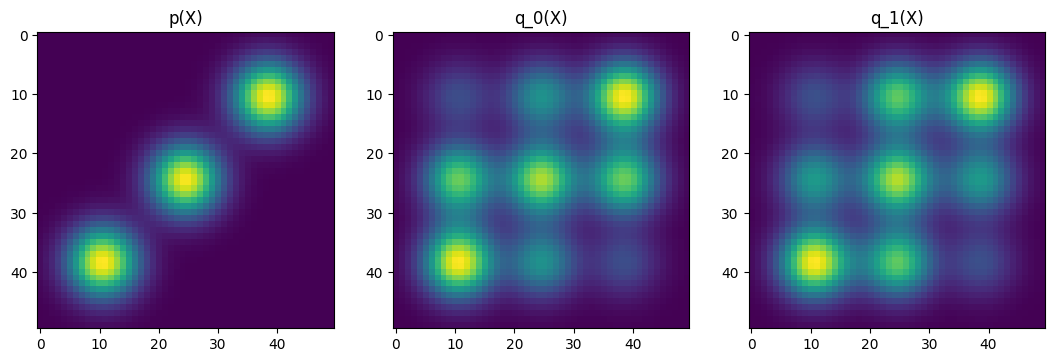

In [1397]:
(fig, axes) = plt.subplots(ncols = 3, figsize = (13, 4))
axes[0].imshow(data_probs.transform([0, 1]).probs.squeeze().numpy(force = True))
axes[1].imshow(joint_dec_0.transform([0, 1]).probs.squeeze().numpy(force = True))
axes[2].imshow(joint_dec_1.transform([0, 1]).probs.squeeze().numpy(force = True))
axes[0].set_title("p(X)")
axes[1].set_title("q_0(X)")
axes[2].set_title("q_1(X)")
plt.show()

### p_i(Z|X_i) vs q_i(Z|X)

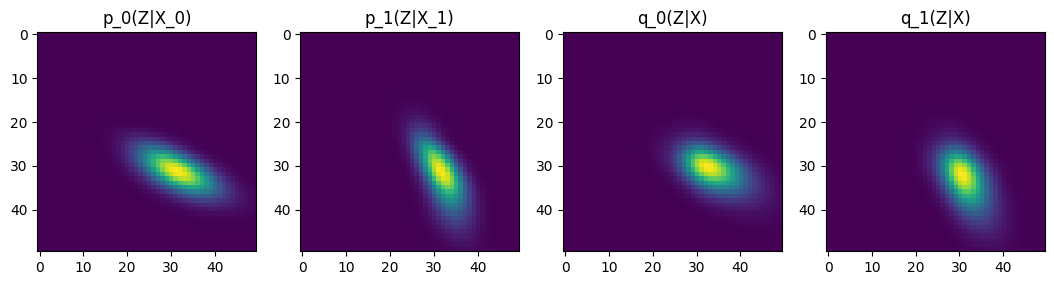

In [1398]:
pos = (35, 12)
(fig, axes) = plt.subplots(ncols = 4, figsize = (13, 4))
axes[0].imshow(joint_enc_0.transform([2, 3], [0]).probs[pos[0]].squeeze().numpy(force = True))
axes[1].imshow(joint_enc_1.transform([2, 3], [1]).probs[:, pos[1]].squeeze().numpy(force = True))
axes[2].imshow(joint_dec_0.probs[pos].squeeze().numpy(force = True))
axes[3].imshow(joint_dec_1.probs[pos].squeeze().numpy(force = True))
axes[0].set_title("p_0(Z|X_0)")
axes[1].set_title("p_1(Z|X_1)")
axes[2].set_title("q_0(Z|X)")
axes[3].set_title("q_1(Z|X)")
plt.show()

### p(Z_j|Z_i) vs q(Z_j|Z_i)

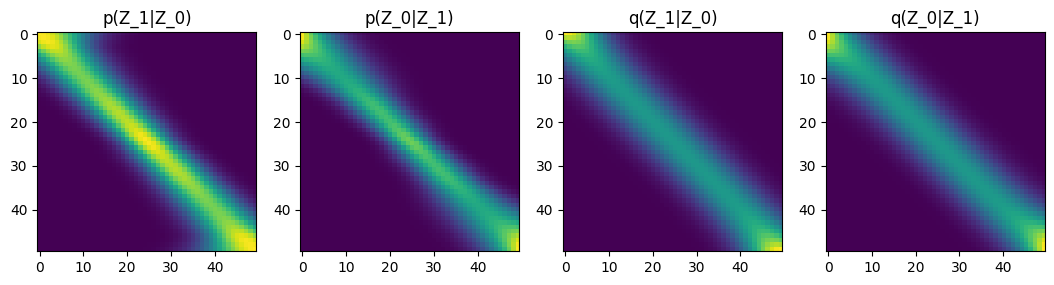

In [1399]:
(fig, axes) = plt.subplots(ncols = 4, figsize = (13, 4))
axes[0].imshow(model["mappers"]["0_1"]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["mappers"]["1_0"]().probs.squeeze().numpy(force = True))
axes[2].imshow(cond_priors["0_1"].probs.squeeze().numpy(force = True))
axes[3].imshow(cond_priors["1_0"].probs.squeeze().numpy(force = True))
axes[0].set_title("p(Z_1|Z_0)")
axes[1].set_title("p(Z_0|Z_1)")
axes[2].set_title("q(Z_1|Z_0)")
axes[3].set_title("q(Z_0|Z_1)")
plt.show()

### q(Z_i) vs p_i(Z_i|X_i)

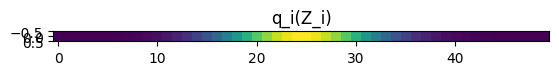

In [1377]:
plt.imshow(marg_priors[0].probs.squeeze()[None].numpy(force = True))
plt.title("q_i(Z_i)")
plt.show()

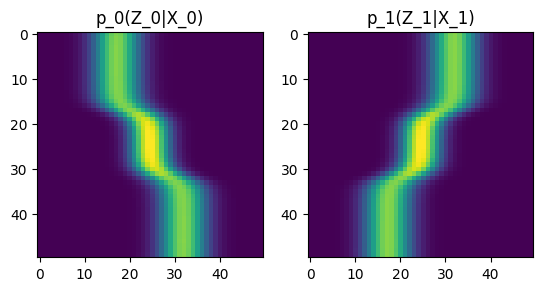

In [1400]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(model["encoders"][0]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["encoders"][1]().probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z_0|X_0)")
axes[1].set_title("p_1(Z_1|X_1)")
plt.show()

### p_i(Z) and q_i(X|Z)

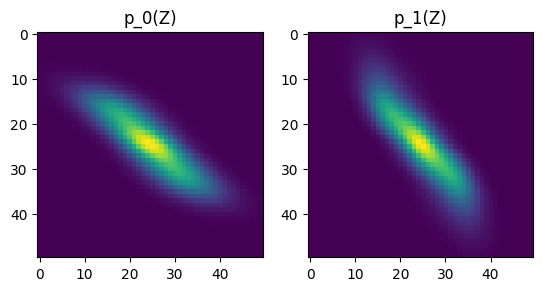

In [1401]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_enc_0.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[1].imshow(joint_enc_1.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z)")
axes[1].set_title("p_1(Z)")
plt.show()

#### Cluster 0

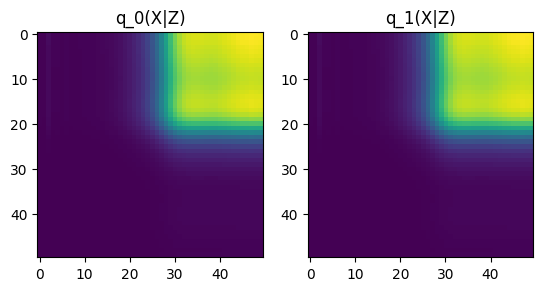

In [1402]:
latent_pos = (15, 15)
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_dec_0.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[1].imshow(joint_dec_1.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[0].set_title("q_0(X|Z)")
axes[1].set_title("q_1(X|Z)")
plt.show()

#### Cluster 1

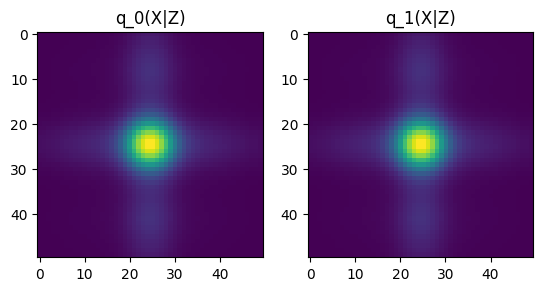

In [1403]:
latent_pos = (25, 25)
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_dec_0.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[1].imshow(joint_dec_1.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[0].set_title("q_0(X|Z)")
axes[1].set_title("q_1(X|Z)")
plt.show()

#### Cluster 2

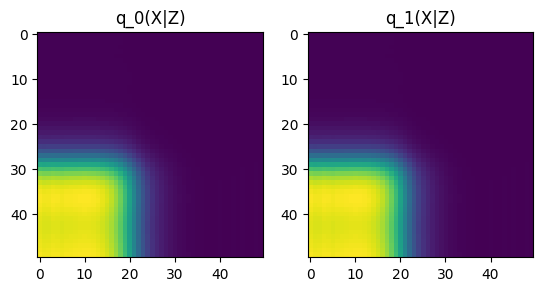

In [1404]:
latent_pos = (40, 40)
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_dec_0.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[1].imshow(joint_dec_1.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[0].set_title("q_0(X|Z)")
axes[1].set_title("q_1(X|Z)")
plt.show()

### p(X_j|X_i) vs q(X_j|X_i) vs int_Z q(X_j|Z)p(Z|X_i)

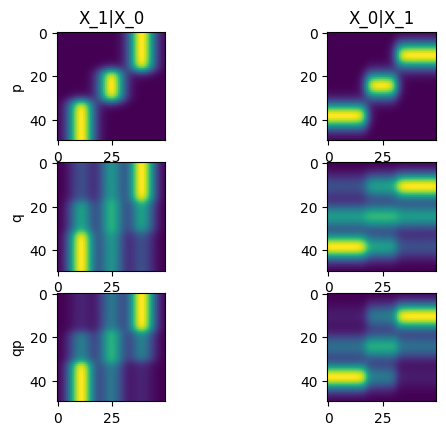

In [1405]:
(fig, (axes_1, axes_2, axes_3)) = plt.subplots(nrows = 3, ncols = 2)
axes_1[0].imshow(data_probs.transform([1], [0]).probs.squeeze().numpy(force = True))
axes_1[1].imshow(data_probs.transform([0], [1]).probs.squeeze().numpy(force = True))
axes_2[0].imshow(joint_dec_0.transform([1], [0]).probs.squeeze().numpy(force = True))
axes_2[1].imshow(joint_dec_1.transform([0], [1]).probs.squeeze().numpy(force = True))
axes_3[0].imshow(joint_enc_0.transform([2, 3], [0, 1]).average(joint_dec_0.transform([1], [2, 3]).probs).squeeze().numpy(force = True))
axes_3[1].imshow(joint_enc_1.transform([2, 3], [0, 1]).average(joint_dec_1.transform([0], [2, 3]).probs).squeeze().numpy(force = True))
axes_1[0].set_title("X_1|X_0")
axes_1[1].set_title("X_0|X_1")
axes_1[0].set_ylabel("p")
axes_2[0].set_ylabel("q")
axes_3[0].set_ylabel("qp")
plt.show()

## Analysis of two cluster, Gaussian decoder var 0.1

### p(X) vs q_i(X)

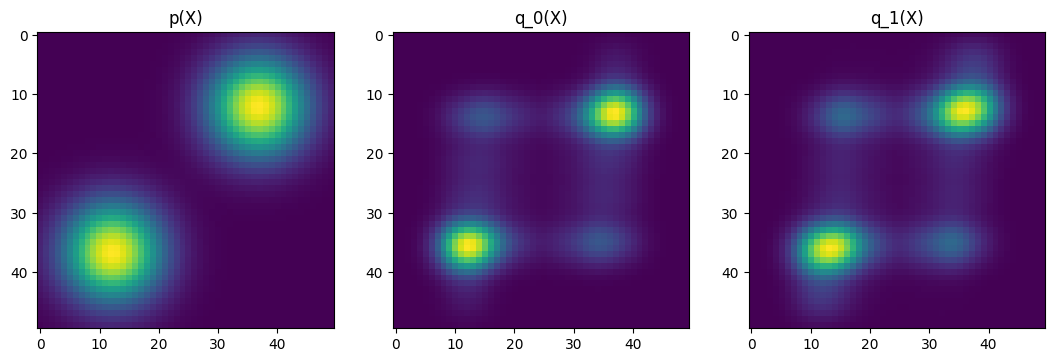

In [1416]:
(fig, axes) = plt.subplots(ncols = 3, figsize = (13, 4))
axes[0].imshow(data_probs.transform([0, 1]).probs.squeeze().numpy(force = True))
axes[1].imshow(joint_dec_0.transform([0, 1]).probs.squeeze().numpy(force = True))
axes[2].imshow(joint_dec_1.transform([0, 1]).probs.squeeze().numpy(force = True))
axes[0].set_title("p(X)")
axes[1].set_title("q_0(X)")
axes[2].set_title("q_1(X)")
plt.show()

### p_i(Z|X_i) vs q_i(Z|X)

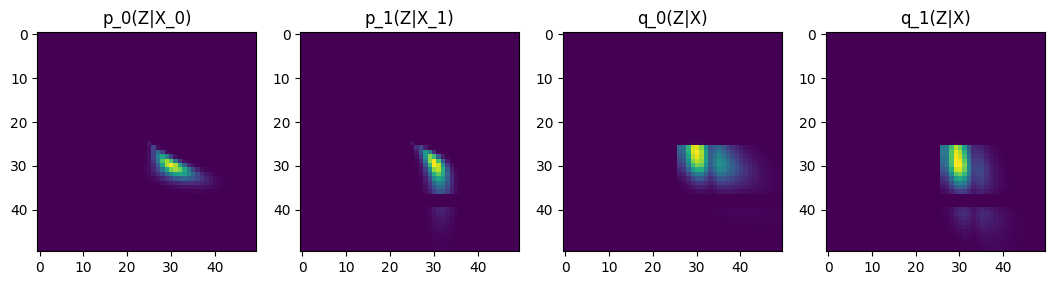

In [1417]:
pos = (35, 12)
(fig, axes) = plt.subplots(ncols = 4, figsize = (13, 4))
axes[0].imshow(joint_enc_0.transform([2, 3], [0]).probs[pos[0]].squeeze().numpy(force = True))
axes[1].imshow(joint_enc_1.transform([2, 3], [1]).probs[:, pos[1]].squeeze().numpy(force = True))
axes[2].imshow(joint_dec_0.probs[pos].squeeze().numpy(force = True))
axes[3].imshow(joint_dec_1.probs[pos].squeeze().numpy(force = True))
axes[0].set_title("p_0(Z|X_0)")
axes[1].set_title("p_1(Z|X_1)")
axes[2].set_title("q_0(Z|X)")
axes[3].set_title("q_1(Z|X)")
plt.show()

### p(Z_j|Z_i) vs q(Z_j|Z_i)

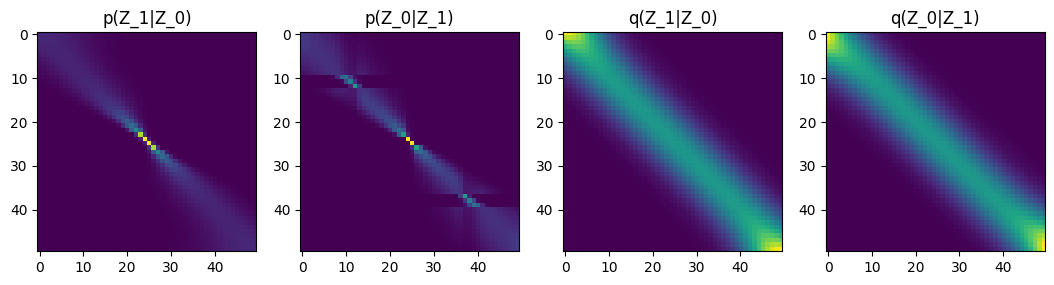

In [1418]:
(fig, axes) = plt.subplots(ncols = 4, figsize = (13, 4))
axes[0].imshow(model["mappers"]["0_1"]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["mappers"]["1_0"]().probs.squeeze().numpy(force = True))
axes[2].imshow(cond_priors["0_1"].probs.squeeze().numpy(force = True))
axes[3].imshow(cond_priors["1_0"].probs.squeeze().numpy(force = True))
axes[0].set_title("p(Z_1|Z_0)")
axes[1].set_title("p(Z_0|Z_1)")
axes[2].set_title("q(Z_1|Z_0)")
axes[3].set_title("q(Z_0|Z_1)")
plt.show()

### q(Z_i) vs p_i(Z_i|X_i)

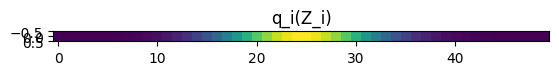

In [1377]:
plt.imshow(marg_priors[0].probs.squeeze()[None].numpy(force = True))
plt.title("q_i(Z_i)")
plt.show()

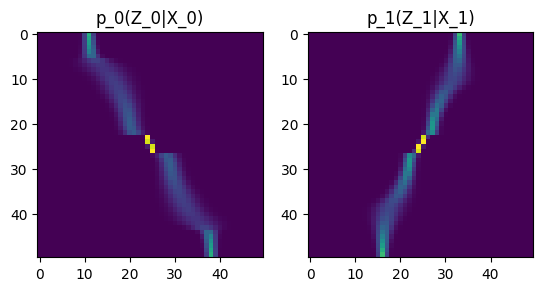

In [1419]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(model["encoders"][0]().probs.squeeze().numpy(force = True))
axes[1].imshow(model["encoders"][1]().probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z_0|X_0)")
axes[1].set_title("p_1(Z_1|X_1)")
plt.show()

### p_i(Z) and q_i(X|Z)

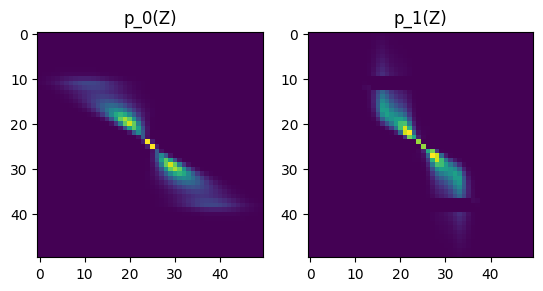

In [1420]:
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_enc_0.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[1].imshow(joint_enc_1.transform([2, 3]).probs.squeeze().numpy(force = True))
axes[0].set_title("p_0(Z)")
axes[1].set_title("p_1(Z)")
plt.show()

#### Cluster 0

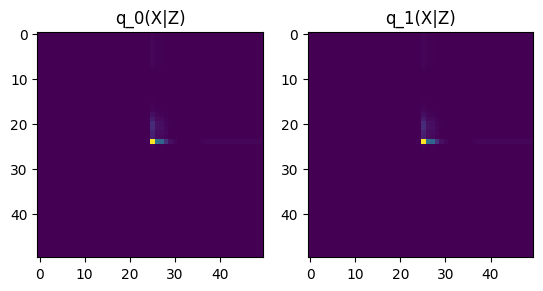

In [1438]:
latent_pos = (20, 20)
(fig, axes) = plt.subplots(ncols = 2)
axes[0].imshow(joint_dec_0.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[1].imshow(joint_dec_1.transform([0, 1], [2, 3]).probs[latent_pos].numpy(force = True))
axes[0].set_title("q_0(X|Z)")
axes[1].set_title("q_1(X|Z)")
plt.show()

### p(X_j|X_i) vs q(X_j|X_i) vs int_Z q(X_j|Z)p(Z|X_i)

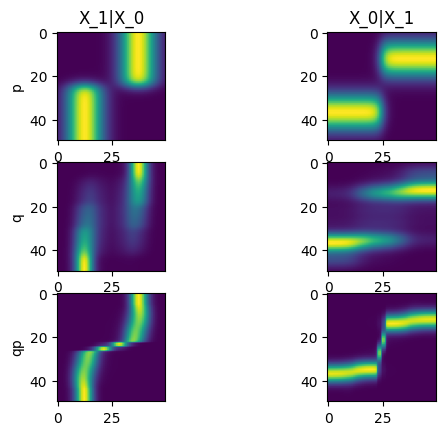

In [1440]:
(fig, (axes_1, axes_2, axes_3)) = plt.subplots(nrows = 3, ncols = 2)
axes_1[0].imshow(data_probs.transform([1], [0]).probs.squeeze().numpy(force = True))
axes_1[1].imshow(data_probs.transform([0], [1]).probs.squeeze().numpy(force = True))
axes_2[0].imshow(joint_dec_0.transform([1], [0]).probs.squeeze().numpy(force = True))
axes_2[1].imshow(joint_dec_1.transform([0], [1]).probs.squeeze().numpy(force = True))
axes_3[0].imshow(joint_enc_0.transform([2, 3], [0, 1]).average(joint_dec_0.transform([1], [2, 3]).probs).squeeze().numpy(force = True))
axes_3[1].imshow(joint_enc_1.transform([2, 3], [0, 1]).average(joint_dec_1.transform([0], [2, 3]).probs).squeeze().numpy(force = True))
axes_1[0].set_title("X_1|X_0")
axes_1[1].set_title("X_0|X_1")
axes_1[0].set_ylabel("p")
axes_2[0].set_ylabel("q")
axes_3[0].set_ylabel("qp")
plt.show()